<h1 align="center"> Initial Plots </h1>

<br>
<i> Import necessary libraries: <i>

In [1]:
import sys
sys.path.append("..")

import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import math
from matplotlib.patches import Ellipse
import time
import random
from sklearn.preprocessing import StandardScaler
np.random.seed(2)

import os
from sklearn.model_selection import train_test_split
from scipy.stats import shapiro 
from scipy.stats import spearmanr
from sklearn.manifold import TSNE
import umap
import seaborn as sns

from src.optimise import capitalize_j, format_case_id

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Matching Samples for Analysis

In [2]:
# Step 1: Load RNA-Seq data
df_rna = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/rna_counts/RNA_counts_141024.csv", header=None, low_memory=False)
df_rna_transposed = df_rna.transpose()
new_header = df_rna_transposed.iloc[1]
df_rna_transposed = df_rna_transposed[2:]
df_rna_transposed.columns = new_header
df_rna_transposed.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces

# Step 3: Filter RNA data for 'ENSG' columns
rna_cols = df_rna_transposed.filter(like='ENSG')

# Step 4: Load and merge image data
df_images = pd.read_excel("/home/kryan24/MRes_Ultrasound/data/metadata/RNA_Sample_Linking2.xlsx")
df_images.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces
df_images['Sample ID'] = df_images['Sample ID'].str.replace(' ', '_')
df_images["SURGICAL"] = df_images["SURGICAL"].str.strip() # Remove whitespaces from SURGICAL

df_merged = pd.merge(df_images, df_rna_transposed, left_on="Sample ID", right_on="Geneid")

# Step 5: Correct data quality issues
df_merged["Extraction site"] = df_merged["Extraction site"].str.strip()
df_merged["Extraction site"] = df_merged["Extraction site"].str.lower()

# Step 6: Read the CSV file into a DataFrame 
df_radiomics = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/metadata/radiomics_clinical_Barcroft_12_01_23.csv", low_memory=False)
# Remove first 2 columns
df_radiomics.drop(df_radiomics.columns[[0, 1]], axis=1, inplace=True)

# Filter columns
df_radiomics = df_radiomics.drop(df_radiomics.iloc[:, 3907:3950], axis=1)
df_radiomics["MAHCINE_CORECCTED"] = df_radiomics["MAHCINE_CORECCTED"].str.strip() # Remove whitespaces from MAHCINE_CORECCTED

# Step 7: Match radiomics data to metadata and filter DataFrame
df_radiomics_meta = df_merged[["Extraction site", "SURGICAL", "CASE ID", "CASE ID2"]]

# Step 8: Merge DataFrames
df_merged2 = pd.merge(df_radiomics_meta, df_radiomics, left_on="CASE ID", right_on="ID")

# Step 9: Correct data quality issues
df_merged2 = df_merged2.drop(["ID"], axis=1)

# Step 10: Keep the same samples for RNA as radiomics data
case_id_list = df_merged2["CASE ID"].tolist()
mask = df_merged["CASE ID"].isin(case_id_list)
df_merged = df_merged[mask]

In [3]:
# Check length of both sample dataframes
print("Number of rows in RNA samples:", df_merged.shape[0])
print("Number of rows in radiomics samples:", df_merged2.shape[0])

Number of rows in RNA samples: 36
Number of rows in radiomics samples: 36


### Pair Images and RNA Data

In [4]:
# Filter radiomics data 
rad_cols = df_merged2.drop(["Extraction site", "SURGICAL", "CASE ID", "CASE ID2", "MAHCINE_CORECCTED"], axis=1)

In [5]:
# Step 1: Prepare image filenames and filter data
image_directory = "/home/kryan24/MRes_Ultrasound/CLIPRNA/images_matched"
image_filenames_rna = []
image_filenames_rad = []
rna_data_filtered = []
rad_data_filtered = []
surgical_rna = []
surgical_rad = []
sample_count_rna = 0 
sample_count_rad = 0 

In [6]:
for index, row in df_merged.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
            if file_name.endswith('.nii.gz') and 'seg' not in file_name:
                file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

                # Check if either case_id or case_id2 is a substring of the filename
                # Only check if the ID is non-empty
                if (case_id and case_id in file_name_corrected) or (case_id2 and case_id2 in file_name_corrected):
                    image_filenames_rna.append(file_name)
                    rna_data_filtered.append(
                        row[rna_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rna.append(row["SURGICAL"])
                    sample_count_rna += 1
                    break  # Only use the first matching image for each row

print(f"Number of Samples: ", sample_count_rna)

Number of Samples:  29


In [7]:
for index, row in df_merged2.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
            if file_name.endswith('.nii.gz') and 'seg' not in file_name:
                file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

                # Check if either case_id or case_id2 is a substring of the filename
                # Only check if the ID is non-empty
                if (case_id and case_id in file_name_corrected) or (case_id2 and case_id2 in file_name_corrected):
                    image_filenames_rad.append(file_name)
                    rad_data_filtered.append(
                        row[rad_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rad.append(row["SURGICAL"])
                    sample_count_rad += 1
                    break  # Only use the first matching image for each row

print(f"Number of Samples: ", sample_count_rad)

Number of Samples:  29


In [8]:
flag = (surgical_rna == surgical_rad)
print(f"Matching Diagnoses: ", flag)

flag2 = (image_filenames_rna == image_filenames_rna)
print(f"Matching Images: ", flag2)

Matching Diagnoses:  True
Matching Images:  True


## Train Data

### Train-test Split

In [9]:
# Convert to DataFrame
rad_data_filtered = pd.DataFrame(rad_data_filtered)
# Convert to DataFrame
rna_data_filtered = pd.DataFrame(rna_data_filtered)

In [10]:
# Step 1: Split into train and test sets
rad_train, rad_test, rna_train, rna_test, surg_train, surg_test, img_train, img_test = train_test_split(rad_data_filtered, rna_data_filtered, surgical_rad, image_filenames_rad, test_size=0.2, random_state=2)

In [11]:
# Convert back to DataFrame
rad_train = pd.DataFrame(rad_train, columns=rad_data_filtered.columns)
rad_test = pd.DataFrame(rad_test, columns=rad_data_filtered.columns)
# Convert back to DataFrame
rna_train = pd.DataFrame(rna_train, columns=rna_data_filtered.columns)
rna_test = pd.DataFrame(rna_test, columns=rna_data_filtered.columns)

In [12]:
print(f"Number of RNA samples: ", rna_train.shape[0])
print(f"Number of radiomics samples: ", rad_train.shape[0])
print(f"Number of image filenames: ", len(img_train))
print(f"Number of diagnoses: ", len(surg_train))
print(f"Image filenames: ", img_train)
print(f"Diagnoses: ", surg_train)

Number of RNA samples:  23
Number of radiomics samples:  23
Number of image filenames:  23
Number of diagnoses:  23
Image filenames:  ['24903_0011.nii.gz', '14984_0039.nii.gz', '14056_3.nii.gz', '25962_0006.nii.gz', '26604_0007.nii.gz', '26428_0020.nii.gz', '187867.nii.gz', '14654_3.nii.gz', '16439_0004.nii.gz', '14024_2.nii.gz', '25970_2.nii.gz', '25607_0005.nii.gz', '14023_3.nii.gz', '16106_0022.nii.gz', '26425_-3.nii.gz', '26417_1.nii.gz', '25827_0006.nii.gz', '18638_0037.nii.gz', 'J630_0008.nii.gz', '26379_5.nii.gz', '18853_0020.nii.gz', '24354_0019.nii.gz', '16134_0049.nii.gz']
Diagnoses:  ['M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'B-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S']


In [13]:
print(f"Number of RNA samples: ", rna_test.shape[0])
print(f"Number of radiomics samples: ", rad_test.shape[0])
print(f"Number of image filenames: ", len(img_test))
print(f"Number of diagnoses: ", len(surg_test))
print(f"Image filenames: ", img_test)
print(f"Diagnoses: ", surg_test)

Number of RNA samples:  6
Number of radiomics samples:  6
Number of image filenames:  6
Number of diagnoses:  6
Image filenames:  ['13291_0010.nii.gz', '12930_3.nii.gz', '18852_0009.nii.gz', '16208_1.nii.gz', '25961_2.nii.gz', '26424_0007.nii.gz']
Diagnoses:  ['M-S', 'B-S', 'B-S', 'B-S', 'M-S', 'M-S']


### Radiomics Tabular Data

In [14]:
# Scale radiomics sample counts
rad_scaler = StandardScaler()
rad_train_df = pd.DataFrame(rad_scaler.fit_transform(rad_train), columns=rad_data_filtered.columns)
rad_train_df.insert(0, "SURGICAL", surg_train)

In [15]:
rad_train_df

,SURGICAL,N.voxels,SNS_vol,SNS_area,SNS_s2v,SNS_sph,SNS_sph_dis,SNS_com_1,SNS_com_2,SNS_max3d,...,GLCM_sumVar_HHH_256gl,GLCM_sumEnt_HHH_256gl,GLCM_difVar_HHH_256gl,GLCM_difEnt_HHH_256gl,GLCM_AutoCorrel_HHH_256gl,GLCM_ClTend_HHH_256gl,GLCM_Homoge1_HHH_256gl,GLCM_IDMN_HHH_256gl,GLCM_IDN_HHH_256gl,GLCM_invVar_HHH_256gl
0,M-S,-0.300256,-0.300256,-0.290585,0.597678,-0.105510,-0.094246,-0.136137,-0.229996,-0.202961,...,-0.099689,-0.458526,0.391541,-0.393965,0.276943,-0.099689,1.140061,0.172859,0.577589,0.389640
1,M-S,0.708814,0.708814,0.736585,1.174269,-0.707359,0.814816,0.702319,-0.512319,0.530002,...,-0.767278,-0.340934,-0.555317,-0.244707,-0.545344,-0.767278,0.349374,0.630998,0.589885,0.487917
2,M-S,0.389183,0.389183,0.387646,-0.430245,-0.528508,0.505664,0.512884,-0.440065,0.297776,...,-0.664274,-0.260948,-0.957752,-0.544056,-1.938336,-0.664274,-0.129701,0.920321,0.795541,0.903431
3,M-S,0.804797,0.804797,0.794266,-1.011904,-0.728401,0.823329,0.862983,-0.528572,0.213413,...,-0.129329,0.237998,-0.025076,0.126134,0.566347,-0.129329,-0.405166,0.161605,0.122408,0.272718
4,M-S,-1.077737,-1.077737,-1.082357,-0.309010,0.693260,-1.015069,-0.975551,0.259959,-1.188107,...,-0.911763,-3.335527,-0.479147,-3.189218,0.584849,-0.911763,3.456858,0.791839,1.492986,-1.088405
5,M-S,-0.641473,-0.641473,-0.648713,0.138136,0.814252,-0.764388,-0.734809,0.710243,-0.009742,...,0.711398,0.687845,1.251147,0.903606,-0.344830,0.711398,-0.716272,-1.058690,-0.917550,-0.399998
6,M-S,1.830349,1.830349,1.815305,-1.205505,-1.141776,1.560108,1.599209,-0.692007,1.821759,...,-0.971624,-0.228353,-1.068968,-0.326319,1.535946,-0.971624,-0.354793,0.922945,0.623815,0.269649
7,M-S,-0.766506,-0.766506,-0.772586,-0.451748,0.554124,-0.752406,-0.709619,0.245511,-0.831604,...,-0.473823,-0.316588,-0.583241,-0.412936,-1.335967,-0.473823,0.419077,0.631495,0.635470,0.245509
8,B-S,0.231533,0.231533,0.221065,-0.992312,-0.416715,0.341899,0.390684,-0.386374,0.248791,...,-1.260083,-0.937788,-1.090119,-0.929800,0.228808,-1.260083,0.509548,1.149639,1.243921,1.998762
9,M-S,-0.642724,-0.642724,-0.639762,0.317509,0.231870,-0.492534,-0.502714,-0.028335,-0.714584,...,0.227803,0.378871,0.503079,0.357899,-1.443137,0.227803,-0.402971,-0.274350,-0.192197,0.349811


In [16]:
# Scale radiomics sample counts
rad_test_df = pd.DataFrame(rad_scaler.transform(rad_test), columns=rad_data_filtered.columns)
rad_test_df.insert(0, "SURGICAL", surg_test)

In [17]:
rad_test_df

,SURGICAL,N.voxels,SNS_vol,SNS_area,SNS_s2v,SNS_sph,SNS_sph_dis,SNS_com_1,SNS_com_2,SNS_max3d,...,GLCM_sumVar_HHH_256gl,GLCM_sumEnt_HHH_256gl,GLCM_difVar_HHH_256gl,GLCM_difEnt_HHH_256gl,GLCM_AutoCorrel_HHH_256gl,GLCM_ClTend_HHH_256gl,GLCM_Homoge1_HHH_256gl,GLCM_IDMN_HHH_256gl,GLCM_IDN_HHH_256gl,GLCM_invVar_HHH_256gl
0,M-S,-0.354384,-0.354384,-0.345940,0.540260,-0.007476,-0.185398,-0.220516,-0.160341,-0.206590,...,-0.222020,-0.282968,-0.083156,-0.340126,1.689428,-0.222020,0.191474,0.177335,0.413888,1.215397
1,B-S,0.289299,0.289299,0.301256,0.419084,-0.496781,0.456292,0.407018,-0.425741,-0.202961,...,-0.679000,-0.202192,-0.520269,-0.287718,-1.203773,-0.679000,-0.118794,0.644606,0.616620,0.982132
2,B-S,-0.929290,-0.929290,-0.937507,-0.667193,0.624517,-0.893797,-0.835826,0.245671,-0.970395,...,-1.117869,-0.994883,-1.154391,-0.977268,2.569243,-1.117869,1.413255,1.178403,1.200711,0.048004
3,B-S,-1.317145,-1.317145,-1.323921,-0.461087,1.030815,-1.343465,-1.286794,0.504152,-1.465690,...,1.381705,0.988686,1.141291,0.930430,-1.747516,1.381705,-0.802945,-1.094815,-1.008092,-0.636333
4,M-S,0.384722,0.384722,0.397021,0.396420,-0.550822,0.538642,0.488177,-0.450665,1.549619,...,-0.369855,0.037312,-0.257915,-0.040500,1.378243,-0.369855,-0.256747,0.405549,0.353259,0.493791
5,M-S,-1.572517,-1.572517,-1.564027,2.062520,1.384019,-1.653006,-1.713466,0.787626,1.037997,...,-2.179672,-3.712603,-2.348192,-3.897961,0.618939,-2.179672,2.509443,2.224327,3.039694,7.993056


### Radiomics - All features

#### Principal Component Analysis (2 Components)

In [18]:
# Seperating out the features
rad_train_all = rad_train_df.drop(["SURGICAL"], axis=1)
# Seperating out the target
rad_train_class = rad_train_df[["SURGICAL"]]

# Create PCA with 2 components
rad_all_pca = PCA(n_components=2)
rad_train_all_prinComps = rad_all_pca.fit_transform(rad_train_all)

# Print DataFrame
df_rad_train_princComps = pd.DataFrame(data=rad_train_all_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rad_train_princComps

,Principal Component 1,Principal Component 2
0,-19.878256,15.718806
1,-10.745140,-21.165185
2,-14.982064,-17.367419
3,20.337649,-12.371930
4,-86.570287,73.603800
5,43.971231,1.394606
6,-34.987280,-31.657083
7,3.697517,2.966846
8,-35.392416,-23.359043
9,35.578311,-0.856139


In [19]:
# Percentage explained by each component
print(rad_all_pca.explained_variance_ratio_)

[0.37439167 0.16477191]


In [20]:
# Final dataframe for plotting the data for class
df_rad_train_pca_class = pd.concat([df_rad_train_princComps, rad_train_class], axis=1)

In [21]:
# Seperating out the features
rad_test_all = rad_test_df.drop(["SURGICAL"], axis=1)
# Seperating out the target
rad_test_class = rad_test_df[["SURGICAL"]]

# Create PCA with 2 components
rad_test_all_prinComps = rad_all_pca.transform(rad_test_all)

# Print DataFrame
df_rad_test_princComps = pd.DataFrame(data=rad_test_all_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rad_test_princComps

,Principal Component 1,Principal Component 2
0,-11.975158,-0.561730
1,-12.314322,-16.525809
2,-37.203454,23.919921
3,50.443311,10.563032
4,-0.312555,-19.437473
5,-67.068406,5.078383


In [22]:
# Percentage explained by each component
print(rad_all_pca.explained_variance_ratio_)

[0.37439167 0.16477191]


In [23]:
# Final dataframe for plotting the data for class
df_rad_test_pca_class = pd.concat([df_rad_test_princComps, rad_test_class], axis=1)

In [24]:
# Function needed to create ellipses for PCA
def eigsorted(cov):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    return vals[order], vecs[:,order]

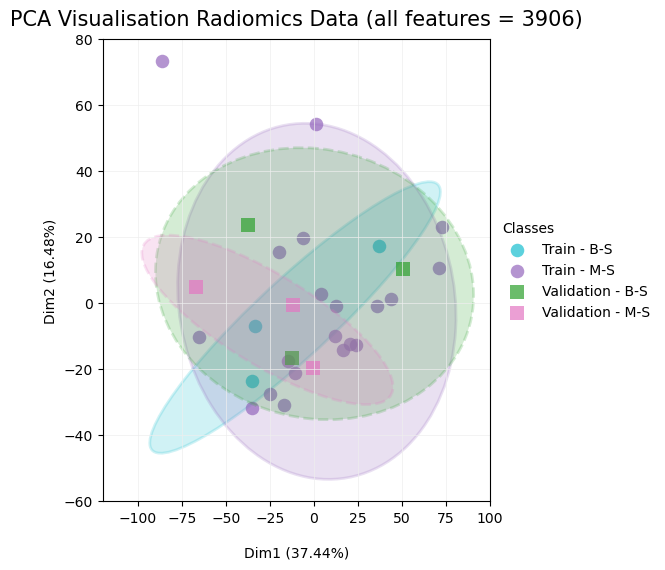

In [25]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours_train = ("#17BECF", "#9467BD")
colours_test = ("#2CA02C", "#E377C2")

# Train data
for target, colour in zip(targets, colours_train):

    # Sort data by class
    indicesToKeep = df_rad_train_pca_class["SURGICAL"] == target
    xdata = df_rad_train_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rad_train_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label="Train - " + target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points

# Test data    
for target, colour in zip(targets, colours_test):

    # Sort data by class
    indicesToKeep = df_rad_test_pca_class["SURGICAL"] == target
    xdata = df_rad_test_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rad_test_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, linestyle="--", alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label="Validation - " + target, # use labels provided above
               c=colour, # use colors provided above
               marker="s",
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation Radiomics Data (all features = 3906)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(rad_all_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-120,100)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(rad_all_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-60,80)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

#### t-SNE

In [26]:
# Cumulative variance function
def cumulative_variance(train_data):
    num_components = []
    variance_list = []

    for i in range(1, 6):
        num_components.append(i)
        pca_obj = PCA(n_components=i)
        pca_obj.fit_transform(train_data)
        tot_var = round((sum(pca_obj.explained_variance_ratio_)*100), 2)
        variance_list.append(tot_var)
        
    return num_components, variance_list

In [27]:
rad_train_comps, rad_train_var = cumulative_variance(rad_train_all)

In [28]:
variance_df = pd.DataFrame(
    {
        "Number of Components": map(str, rad_train_comps),
        "Cumulative Variance": rad_train_var
    }
)

variance_df

,Number of Components,Cumulative Variance
0,1,37.44
1,2,53.92
2,3,62.15
3,4,69.56
4,5,75.88


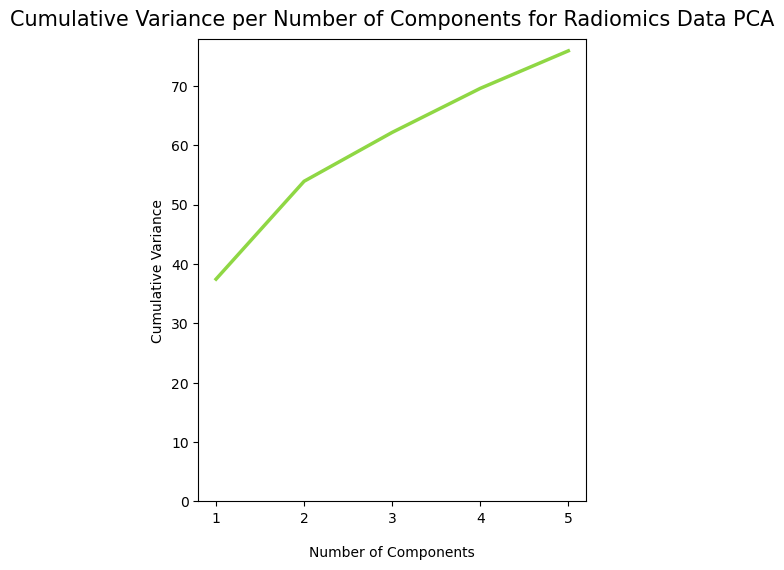

In [29]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.plot(variance_df["Number of Components"], variance_df["Cumulative Variance"], color="#8FD744FF", linewidth=2.5)
ax.set_title("Cumulative Variance per Number of Components for Radiomics Data PCA", fontsize = 15, pad=10)
ax.set_xlabel("Number of Components", fontsize=10, labelpad=15)
ax.set_ylim(ymin=0)
ax.set_ylabel("Cumulative Variance", fontsize=10)
plt.show()

In [30]:
# Seperating out the features
rad_train_all = rad_train_df.drop(["SURGICAL"], axis=1)
# Seperating out the target
rad_train_class = rad_train_df[["SURGICAL"]]

# Create PCA with 2 components
rad_all_pca = PCA(n_components=4)
rad_train_all_prinComps = rad_all_pca.fit_transform(rad_train_all)

# Print DataFrame
df_rad_train_princComps = pd.DataFrame(data=rad_train_all_prinComps, columns=["Principal Component 1", "Principal Component 2", "Principal Component 3", "Principal Component 4"])
df_rad_train_princComps

,Principal Component 1,Principal Component 2,Principal Component 3,Principal Component 4
0,-19.878257,15.718792,-13.561102,-16.648028
1,-10.745140,-21.165185,7.007720,-6.162053
2,-14.982063,-17.367416,-18.521595,-16.659868
3,20.337649,-12.371927,6.630667,0.482824
4,-86.570286,73.603803,-15.359150,28.543579
5,43.971231,1.394606,10.860269,-4.057746
6,-34.987280,-31.657088,-21.436600,23.113832
7,3.697517,2.966840,4.860027,-23.650827
8,-35.392417,-23.359049,11.017126,15.763749
9,35.578311,-0.856134,1.576434,-19.838579


In [31]:
# Percentage explained by each component
print(rad_all_pca.explained_variance_ratio_)

[0.37439167 0.16477191 0.0823657  0.07402189]


In [32]:
# Final dataframe for plotting the data for class
df_rad_train_pca_class = pd.concat([df_rad_train_princComps, rad_train_class], axis=1)

In [33]:
# Seperating out the features
rad_test_all = rad_test_df.drop(["SURGICAL"], axis=1)
# Seperating out the target
rad_test_class = rad_test_df[["SURGICAL"]]

# Create PCA with 2 components
rad_test_all_prinComps = rad_all_pca.transform(rad_test_all)

# Print DataFrame
df_rad_test_princComps = pd.DataFrame(data=rad_test_all_prinComps, columns=["Principal Component 1", "Principal Component 2", "Principal Component 3", "Principal Component 4"])
df_rad_test_princComps

,Principal Component 1,Principal Component 2,Principal Component 3,Principal Component 4
0,-11.975158,-0.561734,9.004643,3.540851
1,-12.314322,-16.525800,-1.641977,-12.466598
2,-37.203454,23.919911,-6.387265,8.668038
3,50.443311,10.563029,14.548052,-10.959063
4,-0.312555,-19.437466,-6.113464,-11.454613
5,-67.068406,5.078371,-3.522613,1.208497


In [34]:
# Percentage explained by each component
print(rad_all_pca.explained_variance_ratio_)

[0.37439167 0.16477191 0.0823657  0.07402189]


In [35]:
# Final dataframe for plotting the data for class
df_rad_test_pca_class = pd.concat([df_rad_test_princComps, rad_test_class], axis=1)

In [36]:
# Final dataframe for t-SNE plot 
df_rad_pca_all = pd.concat([df_rad_train_pca_class, df_rad_test_pca_class], ignore_index=True)
df_rad_pca_all

,Principal Component 1,Principal Component 2,Principal Component 3,Principal Component 4,SURGICAL
0,-19.878257,15.718792,-13.561102,-16.648028,M-S
1,-10.745140,-21.165185,7.007720,-6.162053,M-S
2,-14.982063,-17.367416,-18.521595,-16.659868,M-S
3,20.337649,-12.371927,6.630667,0.482824,M-S
4,-86.570286,73.603803,-15.359150,28.543579,M-S
5,43.971231,1.394606,10.860269,-4.057746,M-S
6,-34.987280,-31.657088,-21.436600,23.113832,M-S
7,3.697517,2.966840,4.860027,-23.650827,M-S
8,-35.392417,-23.359049,11.017126,15.763749,B-S
9,35.578311,-0.856134,1.576434,-19.838579,M-S


In [37]:
# Seperating out the features
rad_all = df_rad_pca_all.drop(["SURGICAL"], axis=1)
# Seperating out the target
rad_class = df_rad_pca_all[["SURGICAL"]]

Determine perplexity to use for t-SNE:

In [38]:
perplexities = np.arange(1, 29)
KL_divergences = []

for i in perplexities:
    # Create tSNE embedding with 2 dimensions
    tsne = TSNE(n_components=2, verbose=0, perplexity=i, n_iter=5000)
    tsne_results = tsne.fit_transform(rad_all)
    tsne_div = tsne.kl_divergence_
    # Add divergence to array
    KL_divergences.append(tsne_div)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and w

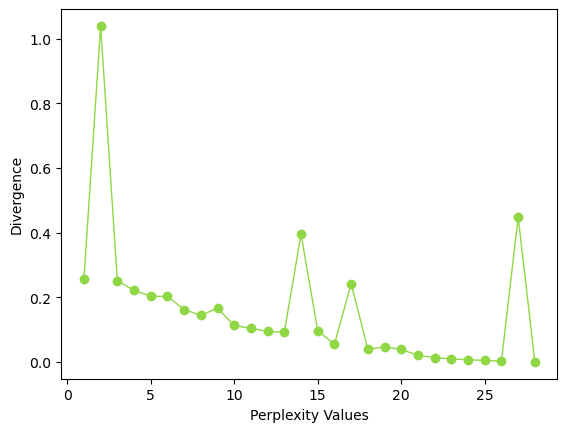

In [39]:
plt.plot(perplexities, KL_divergences, marker="o", color="#8FD744FF", linewidth=1)
plt.xlabel("Perplexity Values")
plt.ylabel("Divergence")

plt.show()

In [40]:
# Create tSNE embedding with 2 dimensions
time_start = time.time()
rad_tsne = TSNE(n_components=2, verbose=1, perplexity=26, n_iter=5000)
rad_tsne_results = rad_tsne.fit_transform(rad_all)

print('t-SNE done! Time elapsed: {} seconds'.format(time.time()-time_start))

[t-SNE] Computing 28 nearest neighbors...
[t-SNE] Indexed 29 samples in 0.000s...
[t-SNE] Computed neighbors for 29 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 29 / 29
[t-SNE] Mean sigma: 86.752800
[t-SNE] KL divergence after 250 iterations with early exaggeration: 41.446800
[t-SNE] KL divergence after 800 iterations: 0.002603
t-SNE done! Time elapsed: 0.11282134056091309 seconds


/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [41]:
# Create DataFrame of tSNE results
df_rad_tsne_class = pd.DataFrame()
df_rad_tsne_class["tsne_one"] = rad_tsne_results[:,0]
df_rad_tsne_class["tsne_two"] = rad_tsne_results[:,1]
df_rad_tsne_class["SURGICAL"] = rad_class

df_rad_tsne_class

,tsne_one,tsne_two,SURGICAL
0,4.028757,-2.745158,M-S
1,3.529809,-2.654451,M-S
2,3.505699,-2.675167,M-S
3,3.635716,-2.184317,M-S
4,4.308193,-3.547425,M-S
5,3.846253,-1.906230,M-S
6,3.314548,-2.997896,M-S
7,3.963629,-2.431791,M-S
8,3.517562,-3.030665,B-S
9,3.867111,-2.023355,M-S


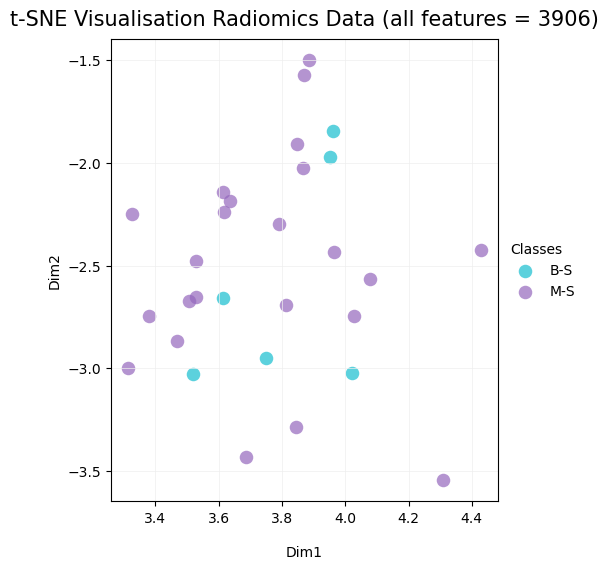

In [42]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rad_tsne_class["SURGICAL"] == target
    xdata = df_rad_tsne_class.loc[indicesToKeep, "tsne_one"]
    ydata = df_rad_tsne_class.loc[indicesToKeep, "tsne_two"]

    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("t-SNE Visualisation Radiomics Data (all features = 3906)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1', fontsize=10, labelpad=15)
ax.set_ylabel('Dim2', fontsize=10)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

#### UMAP

In [43]:
# Seperating out the features
rad_all = df_rad_pca_all.drop(["SURGICAL"], axis=1)
# Seperating out the target
rad_class = df_rad_pca_all[["SURGICAL"]]

In [44]:
def draw_umap_class(n_neighbors=15, min_dist=0.1, n_components=2, metric='euclidean', title='', num_features=""):

    rad_reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric
    )

    rad_umap_results = rad_reducer.fit_transform(num_features)

    fig, ax = plt.subplots(figsize=(5, 6))
    plt.rcParams['axes.spines.left'] = True
    plt.rcParams['axes.spines.right'] = True
    plt.rcParams['axes.spines.top'] = True
    plt.rcParams['axes.spines.bottom'] = True

    targets = ["B-S", "M-S"]
    colours = ["#17BECF", "#9467BD"]

    sns.scatterplot(x=rad_umap_results[:,0], y=rad_umap_results[:,1], hue=rad_class.SURGICAL, palette=colours, hue_order=targets, alpha=0.7, s=95)

    ax.grid(which="major", color="#EEEEEE", linewidth=0.5)
    ax.set_xlabel("Dim1", fontsize=10, labelpad=15)
    ax.set_ylabel("Dim2", fontsize=10, labelpad=15)
    ax.set_title(title, fontsize = 15, pad=10)
    plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
    plt.show()

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


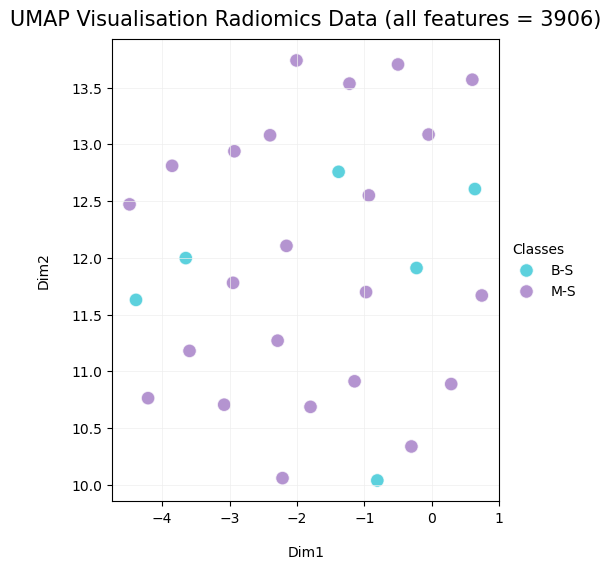

In [45]:
draw_umap_class(n_neighbors=50, min_dist=0.5, title="UMAP Visualisation Radiomics Data (all features = 3906)", num_features=rad_all)

### Radiomics - Spearman Rho Correlation Coefficient

#### Principal Component Analysis (2 Components)

In [46]:
# Seperating out the features
rad_train_all = rad_train_df.drop(["SURGICAL"], axis=1)
# Seperating out the target
rad_train_class_cat = pd.Categorical(rad_train_df["SURGICAL"].astype("category")).codes

In [47]:
# Shapiro-Wilk test for normality
shapiro(rad_train_all)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 89838.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=0.96485560629128, pvalue=1.7903651669190676e-83)

`p-value` = 1.79e-83 -> sample __does not__ come from a normal distribution

In [48]:
thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

def spearman_thresh_function(features, target, thresholds):
    threshold_list = []
    num_features = []

    column_names = features.columns.tolist()

    for threshold in thresholds:
        threshold_list.append(threshold)
        count = 0
        for column in column_names:
            corr, pval = spearmanr(features[column], target)
            if (corr != 0.9):
                if (corr >= threshold and corr <= threshold+1):
                    count += 1
            else:
                if (corr >= threshold):
                    count += 1
        num_features.append(count)

    return threshold_list, num_features

In [49]:
rad_train_thresholds, rad_train_threshold_counts = spearman_thresh_function(rad_train_all, rad_train_class_cat, thresholds)

/tmp/ipykernel_94635/673404981.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [50]:
threshold_df = pd.DataFrame(
    {
        "Threshold": map(str, rad_train_thresholds),
        "Feature Count": rad_train_threshold_counts
    }
)

threshold_df

,Threshold,Feature Count
0,0,2456
1,0.1,1599
2,0.2,691
3,0.3,256
4,0.4,81
5,0.5,6
6,0.6,0
7,0.7,0
8,0.8,0
9,0.9,0


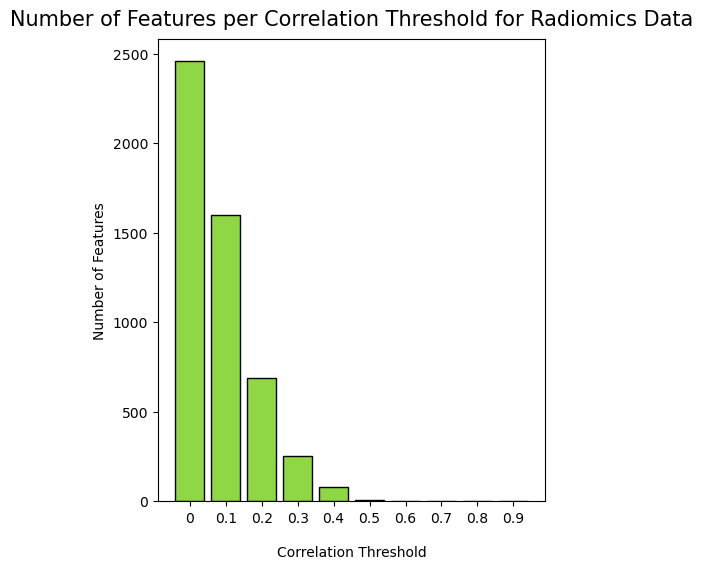

In [51]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.bar(threshold_df["Threshold"], threshold_df["Feature Count"], color="#8FD744FF", edgecolor="black")
ax.set_title("Number of Features per Correlation Threshold for Radiomics Data", fontsize = 15, pad=10)
ax.set_xlabel("Correlation Threshold", fontsize=10, labelpad=15)
ax.set_ylabel("Number of Features", fontsize=10)
plt.show()

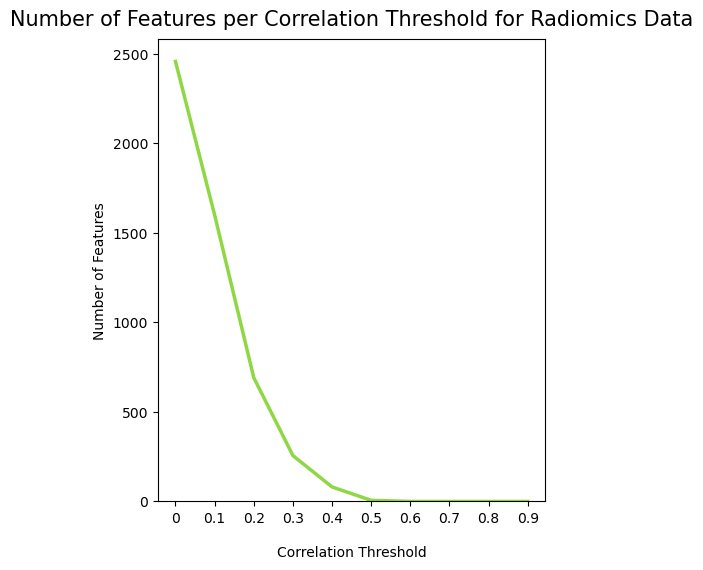

In [52]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.plot(threshold_df["Threshold"], threshold_df["Feature Count"], color="#8FD744FF", linewidth=2.5)
ax.set_title("Number of Features per Correlation Threshold for Radiomics Data", fontsize = 15, pad=10)
ax.set_xlabel("Correlation Threshold", fontsize=10, labelpad=15)
ax.set_ylim(ymin=0)
ax.set_ylabel("Number of Features", fontsize=10)
plt.show()

In [53]:
def spearman_df_function(features, target, threshold):
    feature_names = []
    feature_correlations = []
    
    column_names = features.columns.tolist()

    for column in column_names:
        corr, pval = spearmanr(features[column], target)
        if (corr >= threshold and pval < 0.05):
            feature_names.append(column)
            feature_correlations.append(corr)

    return feature_names, feature_correlations

In [54]:
rad_train_feature_names, rad_train_feature_correlations = spearman_df_function(rad_train_all, rad_train_class_cat, 0.3)

/tmp/ipykernel_94635/2031263521.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [55]:
spearman_df = pd.DataFrame(
    {
        "Features": rad_train_feature_names,
        "Correlations": rad_train_feature_correlations
    }
)

spearman_df

,Features,Correlations
0,GLSZM_ZoneHiGl_4gl,0.467099
1,GLCM_Varian_8gl,0.428174
2,GLCM_Varian_32gl,0.428174
3,GLCM_Varian_64gl,0.428174
4,GLCM_Varian_256gl,0.428174
5,GLSZM_ZoneHiGl_LLL_4gl,0.467099
6,NGTDM_Contra_LLL_8gl,0.428174
7,GLSZM_SzNonUnif_LLL_32gl,0.467099
8,GLSZM_SzVarianc_LLL_32gl,0.525487
9,GLSZM_SzNonUnif_LLL_64gl,0.428174


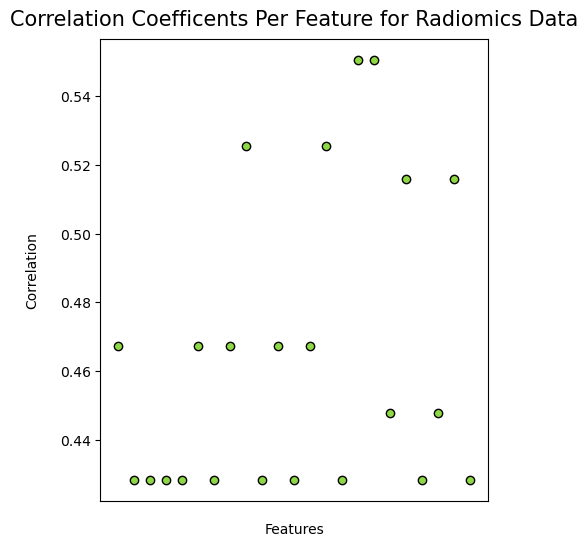

In [56]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.scatter(spearman_df["Features"], spearman_df["Correlations"], color="#8FD744FF", edgecolors="black")
ax.set_title("Correlation Coefficents Per Feature for Radiomics Data", fontsize = 15, pad=10)
ax.set_xlabel("Features", fontsize=10, labelpad=15)
ax.set_ylabel("Correlation", fontsize=10, labelpad=15)

plt.tick_params(bottom=False, labelbottom=False)
plt.show()

In [57]:
# Store spearman features
spearman_rad = spearman_df["Features"].to_list()

In [58]:
# Seperating out the features
rad_train_spear = rad_train_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
rad_train_spear = rad_train_spear.loc[:, rad_train_spear.columns.isin(spearman_rad)]
# Seperating out the target
rad_train_class = rad_train_df[["SURGICAL"]]

# Create PCA with 2 components
rad_spear_pca = PCA(n_components=2)
rad_train_spear_prinComps = rad_spear_pca.fit_transform(rad_train_spear)

# Print DataFrame
df_rad_train_princComps = pd.DataFrame(data=rad_train_spear_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rad_train_princComps

,Principal Component 1,Principal Component 2
0,1.485424,-3.164228
1,-0.840872,-0.246474
2,-0.212010,-0.596177
3,2.973341,2.481783
4,-5.354939,-1.665842
5,5.004591,-1.313424
6,-1.698891,0.904125
7,1.408891,-1.555925
8,-6.663227,2.361018
9,5.385048,-2.062361


In [59]:
# Percentage explained by each component
print(rad_spear_pca.explained_variance_ratio_)

[0.47101986 0.17580093]


In [60]:
# Final dataframe for plotting the data for class
df_rad_train_pca_class = pd.concat([df_rad_train_princComps, rad_train_class], axis=1)

In [61]:
# Seperating out the features
rad_test_spear = rad_test_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
rad_test_spear = rad_test_spear.loc[:, rad_test_spear.columns.isin(spearman_rad)]
# Seperating out the target
rad_test_class = rad_test_df[["SURGICAL"]]

# Create PCA with 2 components
rad_test_spear_prinComps = rad_spear_pca.transform(rad_test_spear)

# Print DataFrame
df_rad_test_princComps = pd.DataFrame(data=rad_test_spear_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rad_test_princComps

,Principal Component 1,Principal Component 2
0,-0.481379,-0.791618
1,0.907823,-1.633897
2,-6.107896,-0.951493
3,3.125771,-1.884862
4,3.981139,-2.622417
5,-6.424449,-1.457937


In [62]:
# Percentage explained by each component
print(rad_spear_pca.explained_variance_ratio_)

[0.47101986 0.17580093]


In [63]:
# Final dataframe for plotting the data for class
df_rad_test_pca_class = pd.concat([df_rad_test_princComps, rad_test_class], axis=1)

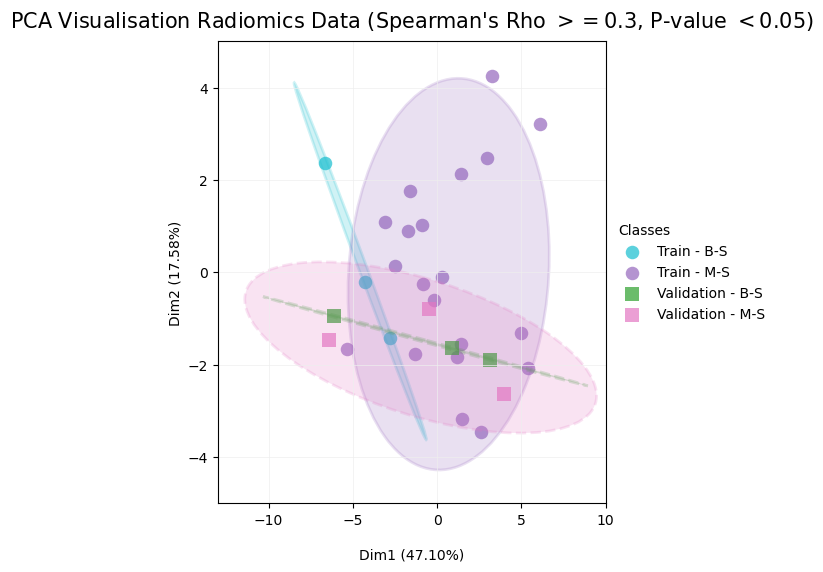

In [64]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours_train = ("#17BECF", "#9467BD")
colours_test = ("#2CA02C", "#E377C2")

# Train data
for target, colour in zip(targets, colours_train):

    # Sort data by class
    indicesToKeep = df_rad_train_pca_class["SURGICAL"] == target
    xdata = df_rad_train_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rad_train_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label="Train - " + target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points

# Test data    
for target, colour in zip(targets, colours_test):

    # Sort data by class
    indicesToKeep = df_rad_test_pca_class["SURGICAL"] == target
    xdata = df_rad_test_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rad_test_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, linestyle="--", alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label="Validation - " + target, # use labels provided above
               c=colour, # use colors provided above
               marker="s",
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation Radiomics Data (Spearman's Rho $ >= 0.3$, P-value $ < 0.05$)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(rad_spear_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-13,10)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(rad_spear_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-5,5)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

#### t-SNE

In [65]:
rad_train_comps, rad_train_var = cumulative_variance(rad_train_spear)

In [66]:
variance_df = pd.DataFrame(
    {
        "Number of Components": map(str, rad_train_comps),
        "Cumulative Variance": rad_train_var
    }
)

variance_df

,Number of Components,Cumulative Variance
0,1,47.10
1,2,64.68
2,3,76.57
3,4,85.08
4,5,91.11


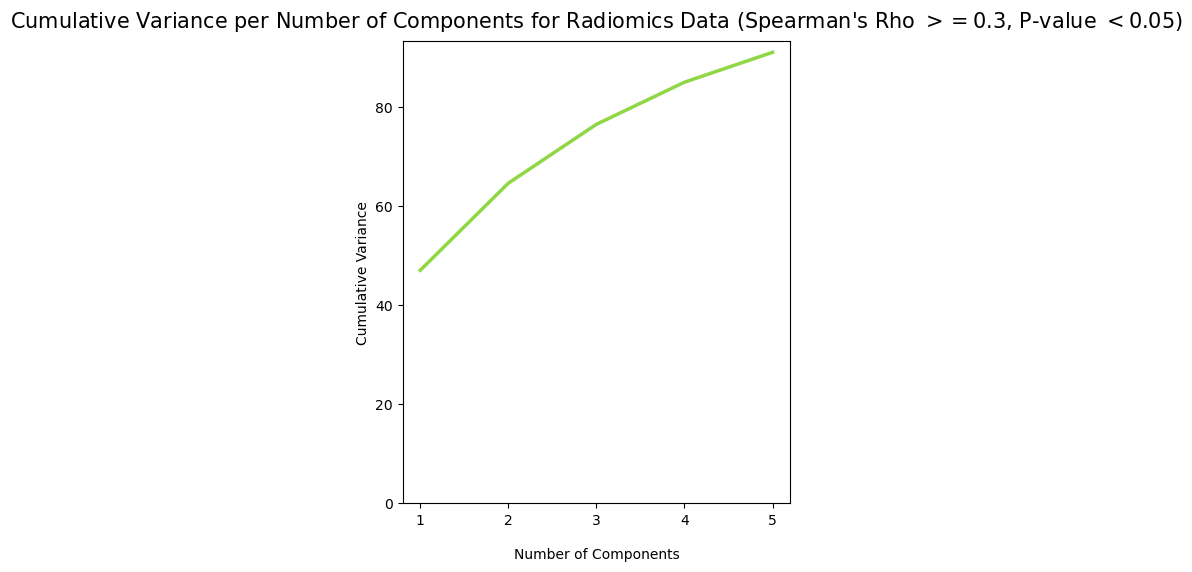

In [67]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.plot(variance_df["Number of Components"], variance_df["Cumulative Variance"], color="#8FD744FF", linewidth=2.5)
ax.set_title("Cumulative Variance per Number of Components for Radiomics Data (Spearman's Rho $ >= 0.3$, P-value $ < 0.05$)", fontsize = 15, pad=10)
ax.set_xlabel("Number of Components", fontsize=10, labelpad=15)
ax.set_ylim(ymin=0)
ax.set_ylabel("Cumulative Variance", fontsize=10)
plt.show()

In [68]:
# Seperating out the features
rad_train_spear = rad_train_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
rad_train_spear = rad_train_spear.loc[:, rad_train_spear.columns.isin(spearman_rad)]
# Seperating out the target
rad_train_class = rad_train_df[["SURGICAL"]]

# Create PCA with 2 components
rad_spear_pca = PCA(n_components=3)
rad_train_spear_prinComps = rad_spear_pca.fit_transform(rad_train_spear)

# Print DataFrame
df_rad_train_princComps = pd.DataFrame(data=rad_train_spear_prinComps, columns=["Principal Component 1", "Principal Component 2", "Principal Component 3"])
df_rad_train_princComps

,Principal Component 1,Principal Component 2,Principal Component 3
0,1.485424,-3.164228,-0.889173
1,-0.840872,-0.246474,-0.853277
2,-0.212010,-0.596177,-0.380109
3,2.973341,2.481783,-2.405523
4,-5.354939,-1.665842,2.001966
5,5.004591,-1.313424,0.111329
6,-1.698891,0.904125,1.729975
7,1.408891,-1.555925,-0.911935
8,-6.663227,2.361018,-0.609218
9,5.385048,-2.062361,-0.319278


In [69]:
# Percentage explained by each component
print(rad_spear_pca.explained_variance_ratio_)

[0.47101986 0.17580093 0.11887268]


In [70]:
# Final dataframe for plotting the data for class
df_rad_train_spear_class = pd.concat([df_rad_train_princComps, rad_train_class], axis=1)

In [71]:
# Seperating out the features
rad_test_spear = rad_test_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
rad_test_spear = rad_test_spear.loc[:, rad_test_spear.columns.isin(spearman_rad)]
# Seperating out the target
rad_test_class = rad_test_df[["SURGICAL"]]

# Create PCA with 2 components
rad_test_spear_prinComps = rad_spear_pca.transform(rad_test_spear)

# Print DataFrame
df_rad_test_princComps = pd.DataFrame(data=rad_test_spear_prinComps, columns=["Principal Component 1", "Principal Component 2", "Principal Component 3"])
df_rad_test_princComps

,Principal Component 1,Principal Component 2,Principal Component 3
0,-0.481379,-0.791618,-0.037488
1,0.907823,-1.633897,2.159475
2,-6.107896,-0.951493,-1.320799
3,3.125771,-1.884862,4.521865
4,3.981139,-2.622417,-3.523812
5,-6.424449,-1.457937,-0.512665


In [72]:
# Percentage explained by each component
print(rad_spear_pca.explained_variance_ratio_)

[0.47101986 0.17580093 0.11887268]


In [73]:
# Final dataframe for plotting the data for class
df_rad_test_spear_class = pd.concat([df_rad_test_princComps, rad_test_class], axis=1)

In [74]:
# Final dataframe for t-SNE plot 
df_rad_spear_all = pd.concat([df_rad_train_spear_class, df_rad_test_spear_class], ignore_index=True)
df_rad_spear_all

,Principal Component 1,Principal Component 2,Principal Component 3,SURGICAL
0,1.485424,-3.164228,-0.889173,M-S
1,-0.840872,-0.246474,-0.853277,M-S
2,-0.212010,-0.596177,-0.380109,M-S
3,2.973341,2.481783,-2.405523,M-S
4,-5.354939,-1.665842,2.001966,M-S
5,5.004591,-1.313424,0.111329,M-S
6,-1.698891,0.904125,1.729975,M-S
7,1.408891,-1.555925,-0.911935,M-S
8,-6.663227,2.361018,-0.609218,B-S
9,5.385048,-2.062361,-0.319278,M-S


In [75]:
# Seperating out the features
rad_all = df_rad_spear_all.drop(["SURGICAL"], axis=1)
# Seperating out the target
rad_class = df_rad_spear_all[["SURGICAL"]]

Determine perplexity to use for t-SNE:

In [76]:
perplexities = np.arange(1, 29)
KL_divergences = []

for i in perplexities:
    # Create tSNE embedding with 2 dimensions
    tsne = TSNE(n_components=2, verbose=0, perplexity=i, n_iter=5000)
    tsne_results = tsne.fit_transform(rad_all)
    tsne_div = tsne.kl_divergence_
    # Add divergence to array
    KL_divergences.append(tsne_div)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and w

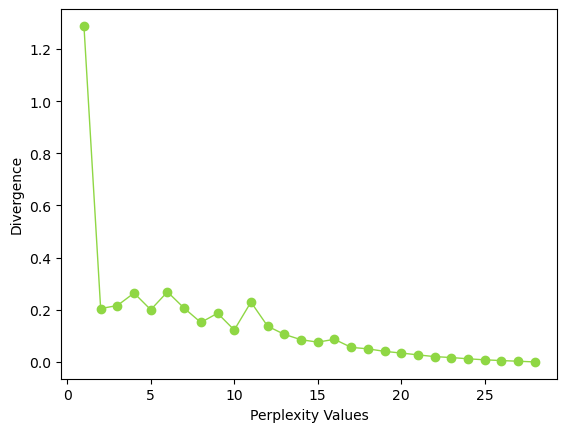

In [77]:
plt.plot(perplexities, KL_divergences, marker="o", color="#8FD744FF", linewidth=1)
plt.xlabel("Perplexity Values")
plt.ylabel("Divergence")

plt.show()

In [78]:
# Create tSNE embedding with 2 dimensions
time_start = time.time()
rad_tsne = TSNE(n_components=2, verbose=1, perplexity=28, n_iter=5000)
rad_tsne_results = rad_tsne.fit_transform(rad_all)

print('t-SNE done! Time elapsed: {} seconds'.format(time.time()-time_start))

[t-SNE] Computing 28 nearest neighbors...
[t-SNE] Indexed 29 samples in 0.000s...
[t-SNE] Computed neighbors for 29 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 29 / 29
[t-SNE] Mean sigma: 89.739359
[t-SNE] KL divergence after 250 iterations with early exaggeration: 41.203438
[t-SNE] KL divergence after 800 iterations: 0.000041
t-SNE done! Time elapsed: 0.11586880683898926 seconds


/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [79]:
# Create DataFrame of tSNE results
df_rad_tsne_class = pd.DataFrame()
df_rad_tsne_class["tsne_one"] = rad_tsne_results[:,0]
df_rad_tsne_class["tsne_two"] = rad_tsne_results[:,1]
df_rad_tsne_class["SURGICAL"] = rad_class

df_rad_tsne_class

,tsne_one,tsne_two,SURGICAL
0,-0.830674,0.075826,M-S
1,-0.814771,0.043274,M-S
2,-0.819756,0.051283,M-S
3,-0.840313,0.085010,M-S
4,-0.754668,0.054300,M-S
5,-0.820488,0.111198,M-S
6,-0.777509,0.061733,M-S
7,-0.827184,0.074489,M-S
8,-0.750032,0.040103,B-S
9,-0.823301,0.113807,M-S


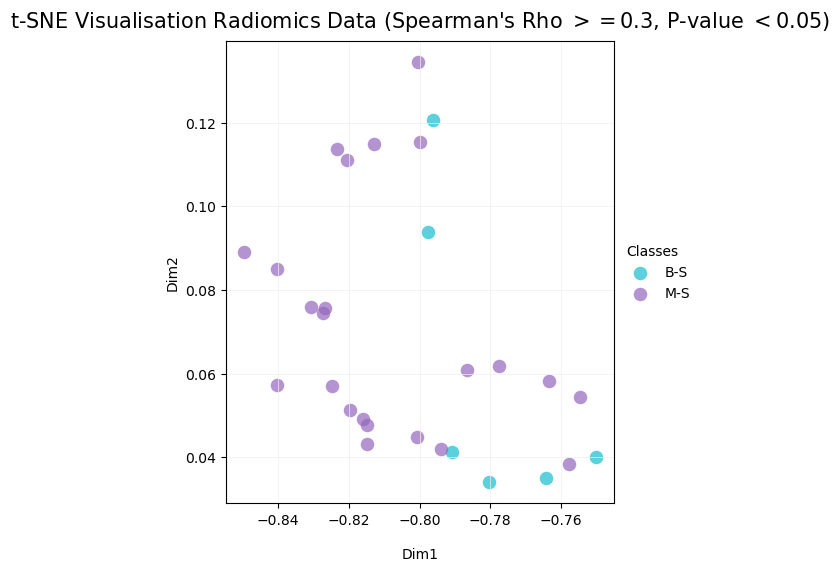

In [80]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rad_tsne_class["SURGICAL"] == target
    xdata = df_rad_tsne_class.loc[indicesToKeep, "tsne_one"]
    ydata = df_rad_tsne_class.loc[indicesToKeep, "tsne_two"]

    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("t-SNE Visualisation Radiomics Data (Spearman's Rho $ >= 0.3$, P-value $ < 0.05$)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1', fontsize=10, labelpad=15)
ax.set_ylabel('Dim2', fontsize=10)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

#### UMAP

In [81]:
# Seperating out the features
rad_all = df_rad_spear_all.drop(["SURGICAL"], axis=1)
# Seperating out the target
rad_class = df_rad_spear_all[["SURGICAL"]]

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


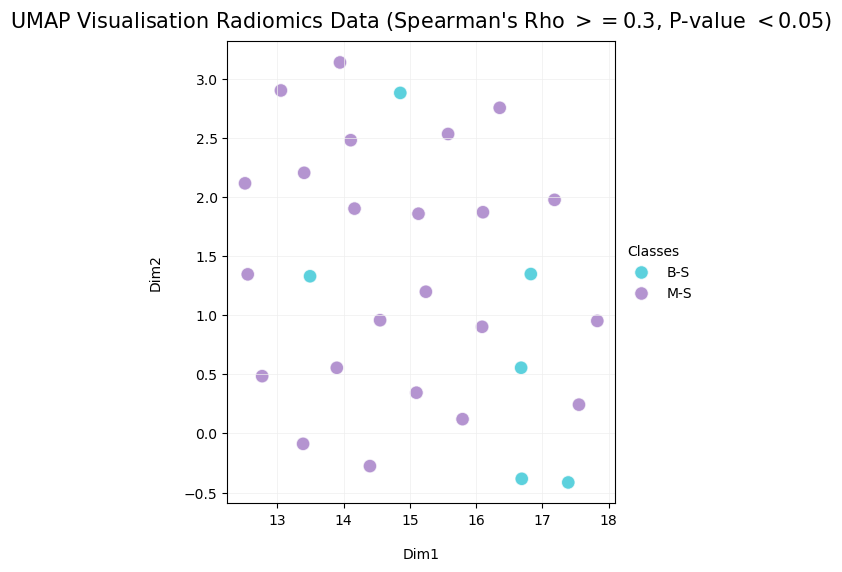

In [82]:
draw_umap_class(n_neighbors=50, min_dist=0.5, title="UMAP Visualisation Radiomics Data (Spearman's Rho $ >= 0.3$, P-value $ < 0.05$)", num_features=rad_all)

### RNA Tabular Data

In [83]:
# Scale RNA sample counts
rna_scaler = StandardScaler()
rna_train_df = pd.DataFrame(rna_scaler.fit_transform(rna_train), columns=rna_data_filtered.columns)
rna_train_df.insert(0, "SURGICAL", surg_train)

In [84]:
rna_train_df

1,SURGICAL,ENSG00000279928,ENSG00000228037,ENSG00000142611,ENSG00000284616,ENSG00000157911,ENSG00000260972,ENSG00000224340,ENSG00000226374,ENSG00000229280,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
0,M-S,0.391489,2.095373,0.845661,0.0,-0.706518,-0.213201,0.0,-0.273434,0.0,...,0.982061,-0.458831,-0.213201,-0.458831,-0.249747,-0.598463,-0.098433,0.593454,0.0,0.405475
1,M-S,-0.608984,3.877982,-0.323115,0.0,0.969914,-0.213201,0.0,-0.273434,0.0,...,-0.462295,-0.458831,-0.213201,-0.458831,-0.608811,-1.222228,-1.356184,-0.633742,0.0,-0.799880
2,M-S,2.392435,-0.412902,-0.345168,0.0,-0.366051,4.690416,0.0,-0.273434,0.0,...,0.542950,2.179449,-0.213201,-0.458831,2.369211,1.905593,2.165519,0.649293,0.0,1.536534
3,M-S,1.391962,-0.570655,-0.179775,0.0,0.022526,-0.213201,0.0,-0.273434,0.0,...,-0.439767,-0.458831,-0.213201,2.179449,-0.197033,-0.315460,0.153118,-0.379423,0.0,-0.643496
4,M-S,0.391489,-0.144721,2.499588,0.0,0.092840,-0.213201,0.0,1.298813,0.0,...,0.925221,-0.458831,-0.213201,-0.458831,-0.159288,0.478861,-0.098433,0.594507,0.0,0.026723
5,M-S,-0.608984,-0.539104,-1.117001,0.0,-1.117300,-0.213201,0.0,4.443309,0.0,...,0.503722,-0.458831,-0.213201,2.179449,-0.517806,-0.230226,-1.607734,0.483332,0.0,1.357289
6,M-S,1.892199,-0.428677,0.139985,0.0,0.126147,-0.213201,0.0,-0.273434,0.0,...,-0.830967,2.179449,-0.213201,-0.458831,-0.740485,-0.584550,-0.601533,-0.532274,0.0,-0.567642
7,M-S,1.892199,-0.334025,-1.183158,0.0,-0.247627,-0.213201,0.0,-0.273434,0.0,...,-0.803359,2.179449,4.690416,2.179449,0.426300,0.350044,0.404668,-0.600500,0.0,0.462625
8,B-S,-0.608984,-0.255148,-0.764163,0.0,0.118745,-0.213201,0.0,-0.273434,0.0,...,-0.076327,-0.458831,-0.213201,-0.458831,-0.470768,1.787090,1.913969,-0.312919,0.0,-0.664278
9,M-S,-0.608984,0.312763,0.128958,0.0,-1.628001,-0.213201,0.0,-0.273434,0.0,...,-0.540527,-0.458831,-0.213201,-0.458831,-0.622723,-0.222019,-0.349983,-0.449639,0.0,-0.869500


In [85]:
# Scale RNA sample counts
rna_test_df = pd.DataFrame(rna_scaler.transform(rna_test), columns=rna_data_filtered.columns)
rna_test_df.insert(0, "SURGICAL", surg_test)

In [86]:
rna_test_df

1,SURGICAL,ENSG00000279928,ENSG00000228037,ENSG00000142611,ENSG00000284616,ENSG00000157911,ENSG00000260972,ENSG00000224340,ENSG00000226374,ENSG00000229280,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
0,M-S,-0.608984,-0.239373,-0.477482,0.0,0.907002,-0.213201,0.0,-0.273434,0.0,...,-0.230147,-0.458831,-0.213201,2.179449,-0.194027,0.074502,0.153118,-0.438142,0.0,-0.039260
1,B-S,-0.608984,-0.570655,-0.003356,0.0,0.714564,-0.213201,0.0,-0.273434,0.0,...,-0.660209,-0.458831,-0.213201,-0.458831,-0.811365,-0.757916,-0.098433,-0.266905,0.0,-0.721948
2,B-S,-0.608984,-0.192047,-0.477482,0.0,-0.958168,-0.213201,0.0,-0.273434,0.0,...,0.059708,-0.458831,-0.213201,4.817730,1.774239,3.224488,4.177921,0.184761,0.0,1.058548
3,B-S,-0.608984,-0.412902,-0.102591,0.0,-0.625102,-0.213201,0.0,-0.273434,0.0,...,-0.843831,-0.458831,-0.213201,-0.458831,0.512576,1.189747,0.907768,-0.571954,0.0,-0.781696
4,M-S,-0.608984,-0.113171,-1.194184,0.0,-0.773132,-0.213201,0.0,-0.273434,0.0,...,1.925039,-0.458831,-0.213201,-0.458831,0.629136,1.063695,1.159318,0.332271,0.0,0.205968
5,M-S,-0.608984,-0.349800,-0.565691,0.0,-1.324541,-0.213201,0.0,-0.273434,0.0,...,2.166943,-0.458831,-0.213201,-0.458831,0.423011,0.902619,2.165519,1.465487,0.0,0.188822


### RNA - All features

#### Principal Component Analysis (2 Components)

In [87]:
# Seperating out the features
rna_train_all = rna_train_df.drop(["SURGICAL"], axis=1)
# Seperating out the target
rna_train_class = rna_train_df[["SURGICAL"]]

# Create PCA with 2 components
rna_all_pca = PCA(n_components=2)
rna_train_all_prinComps = rna_all_pca.fit_transform(rna_train_all)

# Print DataFrame
df_rna_train_princComps = pd.DataFrame(data=rna_train_all_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rna_train_princComps

,Principal Component 1,Principal Component 2
0,25.932256,-61.424045
1,-63.230232,0.681030
2,-88.607539,124.380570
3,-96.674455,75.226515
4,48.611590,-17.674918
5,-100.633662,2.663865
6,106.112936,56.675329
7,-28.712120,-137.819490
8,84.004774,13.051356
9,17.137050,-119.400602


In [88]:
# Percentage explained by each component
print(rna_all_pca.explained_variance_ratio_)

[0.11385162 0.09511209]


In [89]:
# Final dataframe for plotting the data for class
df_rna_train_pca_class = pd.concat([df_rna_train_princComps, rna_train_class], axis=1)

In [90]:
# Seperating out the features
rna_test_all = rna_test_df.drop(["SURGICAL"], axis=1)
# Seperating out the target
rna_test_class = rna_test_df[["SURGICAL"]]

# Create PCA with 2 components
rna_test_all_prinComps = rna_all_pca.transform(rna_test_all)

# Print DataFrame
df_rna_test_princComps = pd.DataFrame(data=rna_test_all_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rna_test_princComps

,Principal Component 1,Principal Component 2
0,-56.695376,-1.191266
1,89.388844,47.679617
2,71.827132,44.582125
3,85.010631,23.231390
4,-78.351158,-21.959986
5,-8.864466,-85.894983


In [91]:
# Percentage explained by each component
print(rna_all_pca.explained_variance_ratio_)

[0.11385162 0.09511209]


In [92]:
# Final dataframe for plotting the data for class
df_rna_test_pca_class = pd.concat([df_rna_test_princComps, rna_test_class], axis=1)

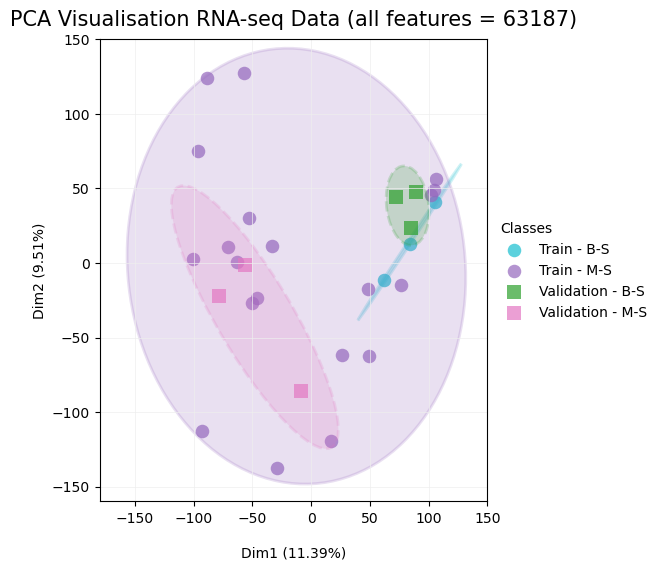

In [93]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours_train = ("#17BECF", "#9467BD")
colours_test = ("#2CA02C", "#E377C2")

# Train data
for target, colour in zip(targets, colours_train):

    # Sort data by class
    indicesToKeep = df_rna_train_pca_class["SURGICAL"] == target
    xdata = df_rna_train_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rna_train_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label="Train - " + target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points

# Test data    
for target, colour in zip(targets, colours_test):

    # Sort data by class
    indicesToKeep = df_rna_test_pca_class["SURGICAL"] == target
    xdata = df_rna_test_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rna_test_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, linestyle="--", alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label="Validation - " + target, # use labels provided above
               c=colour, # use colors provided above
               marker="s",
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation RNA-seq Data (all features = 63187)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(rna_all_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-180,150)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(rna_all_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-160,150)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

#### t-SNE

In [94]:
rna_train_comps, rna_train_var = cumulative_variance(rna_train_all)

In [95]:
variance_df = pd.DataFrame(
    {
        "Number of Components": map(str, rna_train_comps),
        "Cumulative Variance": rna_train_var
    }
)

variance_df

,Number of Components,Cumulative Variance
0,1,11.39
1,2,20.90
2,3,29.83
3,4,36.61
4,5,43.17


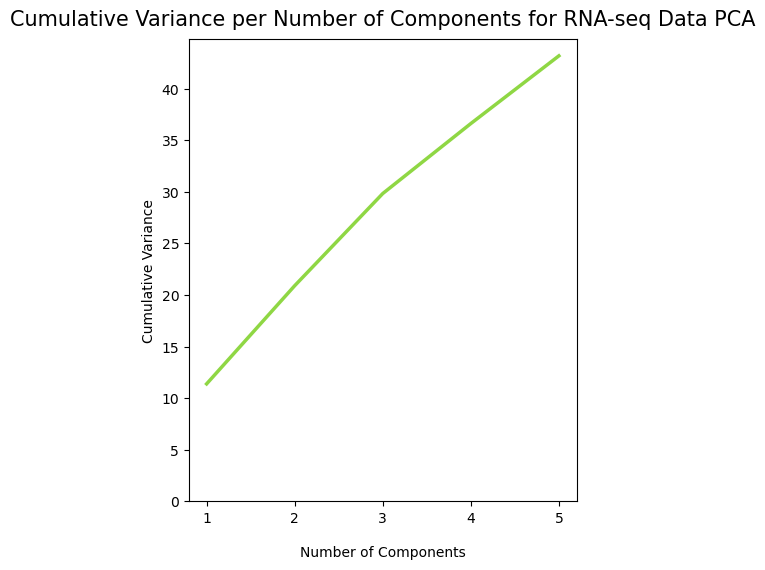

In [96]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.plot(variance_df["Number of Components"], variance_df["Cumulative Variance"], color="#8FD744FF", linewidth=2.5)
ax.set_title("Cumulative Variance per Number of Components for RNA-seq Data PCA", fontsize = 15, pad=10)
ax.set_xlabel("Number of Components", fontsize=10, labelpad=15)
ax.set_ylim(ymin=0)
ax.set_ylabel("Cumulative Variance", fontsize=10)
plt.show()

In [97]:
# Seperating out the features
rna_train_all = rna_train_df.drop(["SURGICAL"], axis=1)
# Seperating out the target
rna_train_class = rna_train_df[["SURGICAL"]]

# Create PCA with 2 components
rna_all_pca = PCA(n_components=3)
rna_train_all_prinComps = rna_all_pca.fit_transform(rna_train_all)

# Print DataFrame
df_rna_train_princComps = pd.DataFrame(data=rna_train_all_prinComps, columns=["Principal Component 1", "Principal Component 2", "Principal Component 3"])
df_rna_train_princComps

,Principal Component 1,Principal Component 2,Principal Component 3
0,26.074159,-60.754012,-22.955770
1,-63.151698,0.866659,131.606037
2,-88.708410,124.139589,-120.414835
3,-96.532447,75.455913,5.298203
4,48.875713,-17.084431,-18.830204
5,-100.649847,2.575871,-72.272579
6,106.138381,56.727864,-17.532702
7,-28.628726,-137.690080,15.447128
8,84.014306,12.848600,-37.751038
9,17.221680,-119.285742,-40.119894


In [98]:
# Percentage explained by each component
print(rna_all_pca.explained_variance_ratio_)

[0.11385093 0.09510852 0.08938092]


In [99]:
# Final dataframe for plotting the data for class
df_rna_train_pca_class = pd.concat([df_rna_train_princComps, rna_train_class], axis=1)

In [100]:
# Seperating out the features
rna_test_all = rna_test_df.drop(["SURGICAL"], axis=1)
# Seperating out the target
rna_test_class = rna_test_df[["SURGICAL"]]

# Create PCA with 2 components
rna_test_all_prinComps = rna_all_pca.transform(rna_test_all)

# Print DataFrame
df_rna_test_princComps = pd.DataFrame(data=rna_test_all_prinComps, columns=["Principal Component 1", "Principal Component 2", "Principal Component 3"])
df_rna_test_princComps

,Principal Component 1,Principal Component 2,Principal Component 3
0,-56.659850,-1.086197,70.696525
1,89.348509,47.593930,-0.126193
2,71.852134,44.624002,-47.002161
3,84.977581,23.208156,-4.410304
4,-78.271573,-21.752852,0.240330
5,-8.798795,-85.696941,-41.651355


In [101]:
# Percentage explained by each component
print(rna_all_pca.explained_variance_ratio_)

[0.11385093 0.09510852 0.08938092]


In [102]:
# Final dataframe for plotting the data for class
df_rna_test_pca_class = pd.concat([df_rna_test_princComps, rna_test_class], axis=1)

In [103]:
# Final dataframe for t-SNE plot 
df_rna_pca_all = pd.concat([df_rna_train_pca_class, df_rna_test_pca_class], ignore_index=True)
df_rna_pca_all

,Principal Component 1,Principal Component 2,Principal Component 3,SURGICAL
0,26.074159,-60.754012,-22.955770,M-S
1,-63.151698,0.866659,131.606037,M-S
2,-88.708410,124.139589,-120.414835,M-S
3,-96.532447,75.455913,5.298203,M-S
4,48.875713,-17.084431,-18.830204,M-S
5,-100.649847,2.575871,-72.272579,M-S
6,106.138381,56.727864,-17.532702,M-S
7,-28.628726,-137.690080,15.447128,M-S
8,84.014306,12.848600,-37.751038,B-S
9,17.221680,-119.285742,-40.119894,M-S


In [104]:
# Seperating out the features
rna_all = df_rna_pca_all.drop(["SURGICAL"], axis=1)
# Seperating out the target
rna_class = df_rna_pca_all[["SURGICAL"]]

Determine perplexity to use for t-SNE:

In [105]:
perplexities = np.arange(1, 29)
KL_divergences = []

for i in perplexities:
    # Create tSNE embedding with 2 dimensions
    tsne = TSNE(n_components=2, verbose=0, perplexity=i, n_iter=5000)
    tsne_results = tsne.fit_transform(rna_all)
    tsne_div = tsne.kl_divergence_
    # Add divergence to array
    KL_divergences.append(tsne_div)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and w

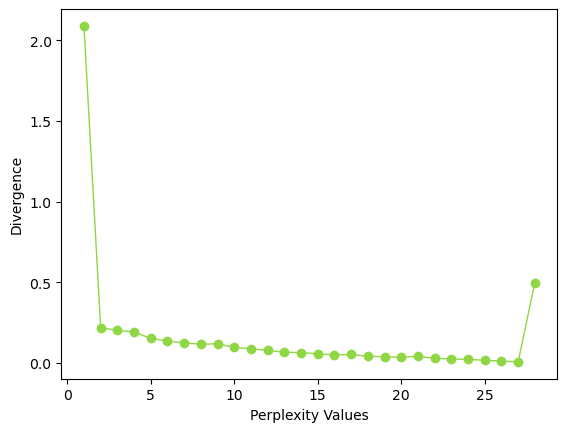

In [106]:
plt.plot(perplexities, KL_divergences, marker="o", color="#8FD744FF", linewidth=1)
plt.xlabel("Perplexity Values")
plt.ylabel("Divergence")

plt.show()

In [107]:
# Create tSNE embedding with 2 dimensions
time_start = time.time()
rna_tsne = TSNE(n_components=2, verbose=1, perplexity=26, n_iter=5000)
rna_tsne_results = rna_tsne.fit_transform(rna_all)

print('t-SNE done! Time elapsed: {} seconds'.format(time.time()-time_start))

[t-SNE] Computing 28 nearest neighbors...
[t-SNE] Indexed 29 samples in 0.000s...
[t-SNE] Computed neighbors for 29 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 29 / 29
[t-SNE] Mean sigma: 196.245052
[t-SNE] KL divergence after 250 iterations with early exaggeration: 40.951118
[t-SNE] KL divergence after 1000 iterations: 0.011184
t-SNE done! Time elapsed: 0.14106345176696777 seconds


/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [108]:
# Create DataFrame of tSNE results
df_rna_tsne_class = pd.DataFrame()
df_rna_tsne_class["tsne_one"] = rna_tsne_results[:,0]
df_rna_tsne_class["tsne_two"] = rna_tsne_results[:,1]
df_rna_tsne_class["SURGICAL"] = rna_class

df_rna_tsne_class

,tsne_one,tsne_two,SURGICAL
0,5.516947,-0.589968,M-S
1,4.960393,-1.417980,M-S
2,4.138625,-0.654544,M-S
3,4.488709,-1.007262,M-S
4,5.302499,-0.380419,M-S
5,4.612721,-1.017196,M-S
6,4.954771,0.025787,M-S
7,5.703817,-1.033621,M-S
8,5.210923,-0.116921,B-S
9,5.765101,-0.701425,M-S


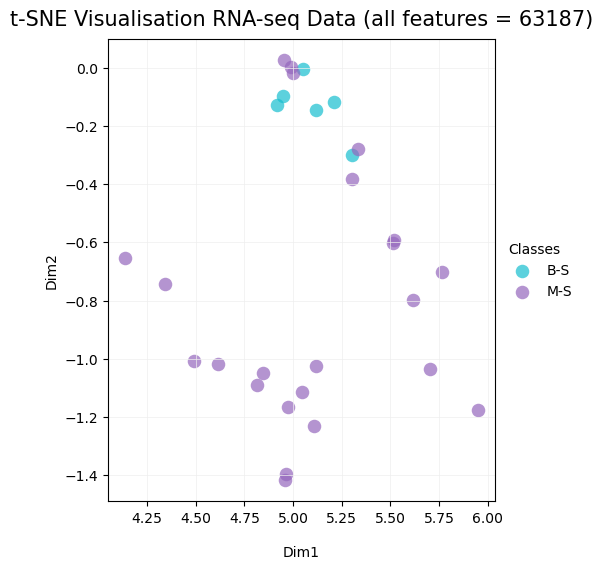

In [109]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rna_tsne_class["SURGICAL"] == target
    xdata = df_rna_tsne_class.loc[indicesToKeep, "tsne_one"]
    ydata = df_rna_tsne_class.loc[indicesToKeep, "tsne_two"]

    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("t-SNE Visualisation RNA-seq Data (all features = 63187)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1', fontsize=10, labelpad=15)
ax.set_ylabel('Dim2', fontsize=10)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

#### UMAP

In [110]:
# Seperating out the features
rna_all = df_rna_pca_all.drop(["SURGICAL"], axis=1)
# Seperating out the target
rna_class = df_rna_pca_all[["SURGICAL"]]

In [111]:
def draw_umap_rna_class(n_neighbors=15, min_dist=0.1, n_components=2, metric='euclidean', title='', num_features=""):

    rna_reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric
    )

    rna_umap_results = rna_reducer.fit_transform(num_features)

    fig, ax = plt.subplots(figsize=(5, 6))
    plt.rcParams['axes.spines.left'] = True
    plt.rcParams['axes.spines.right'] = True
    plt.rcParams['axes.spines.top'] = True
    plt.rcParams['axes.spines.bottom'] = True

    targets = ["B-S", "M-S"]
    colours = ["#17BECF", "#9467BD"]

    sns.scatterplot(x=rna_umap_results[:,0], y=rna_umap_results[:,1], hue=rna_class.SURGICAL, palette=colours, hue_order=targets, alpha=0.7, s=95)

    ax.grid(which="major", color="#EEEEEE", linewidth=0.5)
    ax.set_xlabel("Dim1", fontsize=10, labelpad=15)
    ax.set_ylabel("Dim2", fontsize=10, labelpad=15)
    ax.set_title(title, fontsize = 15, pad=10)
    plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
    plt.show()

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


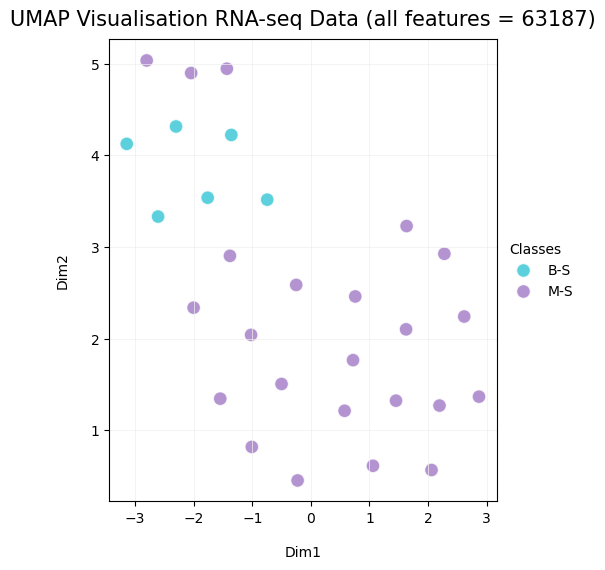

In [112]:
draw_umap_rna_class(n_neighbors=50, min_dist=0.5, title="UMAP Visualisation RNA-seq Data (all features = 63187)", num_features=rna_all)

### RNA - Spearman Rho Correlation Coefficient

#### Principal Component Analysis (2 Components)

In [113]:
# Seperating out the features
rna_train_all = rna_train_df.drop(["SURGICAL"], axis=1)
# Seperating out the target
rna_train_class_cat = pd.Categorical(rna_train_df["SURGICAL"].astype("category")).codes

In [114]:
# Shapiro-Wilk test for normality
shapiro(rna_train_all)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 1453301.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=0.7464759218640797, pvalue=1.0184550159659861e-190)

`p-value` = 1.02e-190 -> sample __does not__ come from a normal distribution

In [115]:
rna_train_thresholds, rna_train_threshold_counts = spearman_thresh_function(rna_train_all, rna_train_class_cat, thresholds)

/tmp/ipykernel_94635/673404981.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [116]:
threshold_df = pd.DataFrame(
    {
        "Threshold": map(str, rna_train_thresholds),
        "Feature Count": rna_train_threshold_counts
    }
)

threshold_df

,Threshold,Feature Count
0,0,31711
1,0.1,22188
2,0.2,12114
3,0.3,5481
4,0.4,1787
5,0.5,245
6,0.6,0
7,0.7,0
8,0.8,0
9,0.9,0


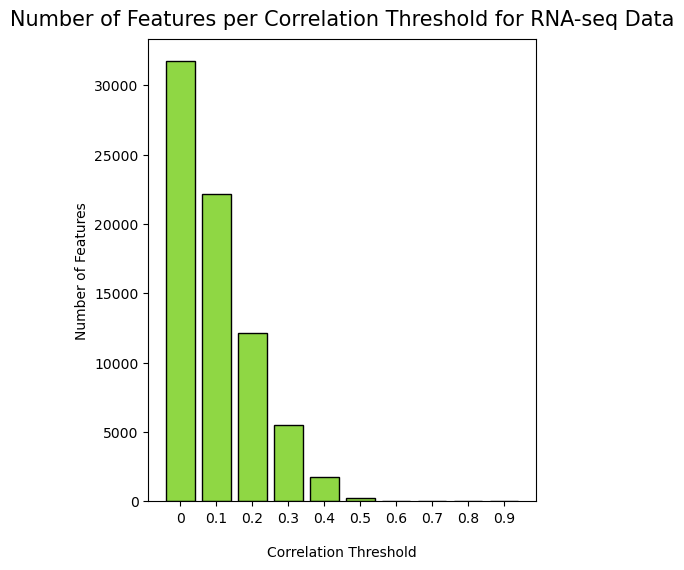

In [117]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.bar(threshold_df["Threshold"], threshold_df["Feature Count"], color="#8FD744FF", edgecolor="black")
ax.set_title("Number of Features per Correlation Threshold for RNA-seq Data", fontsize = 15, pad=10)
ax.set_xlabel("Correlation Threshold", fontsize=10, labelpad=15)
ax.set_ylabel("Number of Features", fontsize=10)
plt.show()

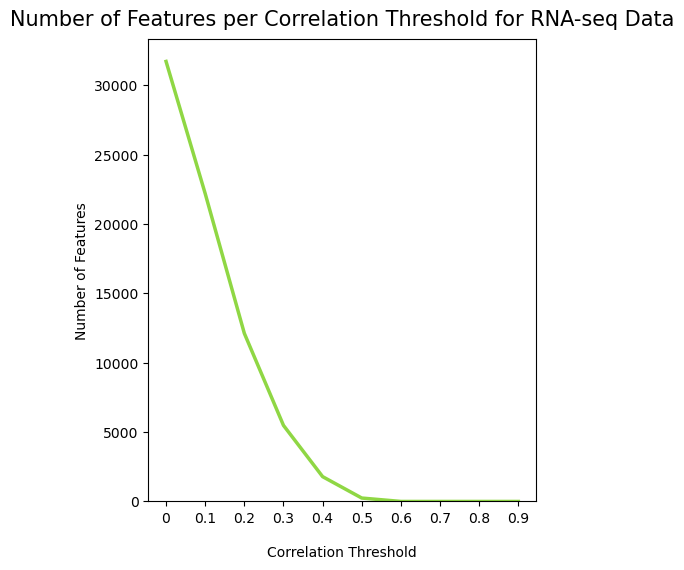

In [118]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.plot(threshold_df["Threshold"], threshold_df["Feature Count"], color="#8FD744FF", linewidth=2.5)
ax.set_title("Number of Features per Correlation Threshold for RNA-seq Data", fontsize = 15, pad=10)
ax.set_xlabel("Correlation Threshold", fontsize=10, labelpad=15)
ax.set_ylim(ymin=0)
ax.set_ylabel("Number of Features", fontsize=10)
plt.show()

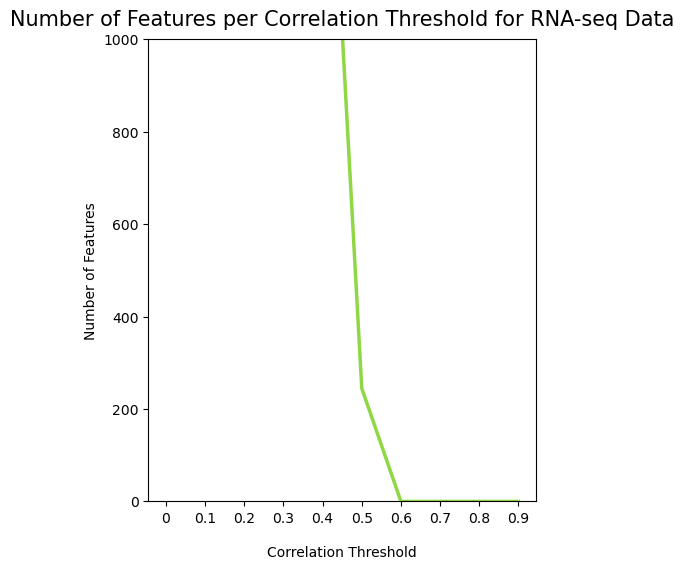

In [119]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.plot(threshold_df["Threshold"], threshold_df["Feature Count"], color="#8FD744FF", linewidth=2.5)
ax.set_title("Number of Features per Correlation Threshold for RNA-seq Data", fontsize = 15, pad=10)
ax.set_xlabel("Correlation Threshold", fontsize=10, labelpad=15)
ax.set_ylim(ymin=0, ymax=1000)
ax.set_ylabel("Number of Features", fontsize=10)
plt.show()

In [120]:
rna_train_feature_names, rna_train_feature_correlations = spearman_df_function(rna_train_all, rna_train_class_cat, 0.5)

/tmp/ipykernel_94635/2031263521.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [121]:
spearman_df = pd.DataFrame(
    {
        "Features": rna_train_feature_names,
        "Correlations": rna_train_feature_correlations
    }
)

spearman_df

,Features,Correlations
0,ENSG00000189280,0.558978
1,ENSG00000163873,0.536678
2,ENSG00000143185,0.500767
3,ENSG00000162782,0.506525
4,ENSG00000197472,0.528498
...,...,...
240,ENSG00000161091,0.506024
241,ENSG00000225335,0.545354
242,ENSG00000242114,0.525487
243,ENSG00000128218,0.557859


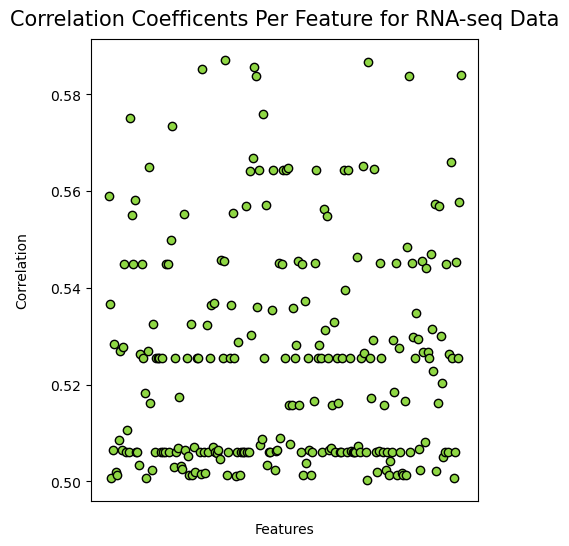

In [122]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.scatter(spearman_df["Features"], spearman_df["Correlations"], color="#8FD744FF", edgecolors="black")
ax.set_title("Correlation Coefficents Per Feature for RNA-seq Data", fontsize = 15, pad=10)
ax.set_xlabel("Features", fontsize=10, labelpad=15)
ax.set_ylabel("Correlation", fontsize=10, labelpad=15)

plt.tick_params(bottom=False, labelbottom=False)
plt.show()

In [123]:
# Store spearman features
spearman_rna = spearman_df["Features"].to_list()

In [124]:
# Seperating out the features
rna_train_spear = rna_train_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
rna_train_spear = rna_train_spear.loc[:, rna_train_spear.columns.isin(spearman_rna)]
# Seperating out the target
rna_train_class = rna_train_df[["SURGICAL"]]

# Create PCA with 2 components
rna_spear_pca = PCA(n_components=2)
rna_train_spear_prinComps = rna_spear_pca.fit_transform(rna_train_spear)

# Print DataFrame
df_rna_train_princComps = pd.DataFrame(data=rna_train_spear_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rna_train_princComps

,Principal Component 1,Principal Component 2
0,-5.096833,0.997949
1,11.564294,11.553006
2,6.271019,-10.808852
3,10.507070,-10.606647
4,-4.509068,1.909222
5,9.192113,0.033136
6,-9.661241,-1.276639
7,4.563032,6.431911
8,-14.260530,-0.414119
9,-2.214691,-0.082223


In [125]:
# Percentage explained by each component
print(rna_spear_pca.explained_variance_ratio_)

[0.25846348 0.12574327]


In [126]:
# Final dataframe for plotting the data for class
df_rna_train_pca_class = pd.concat([df_rna_train_princComps, rna_train_class], axis=1)

In [127]:
# Seperating out the features
rna_test_spear = rna_test_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
rna_test_spear = rna_test_spear.loc[:, rna_test_spear.columns.isin(spearman_rna)]
# Seperating out the target
rna_test_class = rna_test_df[["SURGICAL"]]

# Create PCA with 2 components
rna_test_spear_prinComps = rna_spear_pca.transform(rna_test_spear)

# Print DataFrame
df_rna_test_princComps = pd.DataFrame(data=rna_test_spear_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rna_test_princComps

,Principal Component 1,Principal Component 2
0,10.442003,6.846282
1,-9.156196,-0.780532
2,-8.499343,-1.681048
3,-9.307977,-0.441684
4,9.466755,4.290672
5,-2.721215,-0.025523


In [128]:
# Percentage explained by each component
print(rna_spear_pca.explained_variance_ratio_)

[0.25846348 0.12574327]


In [129]:
# Final dataframe for plotting the data for class
df_rna_test_pca_class = pd.concat([df_rna_test_princComps, rna_test_class], axis=1)

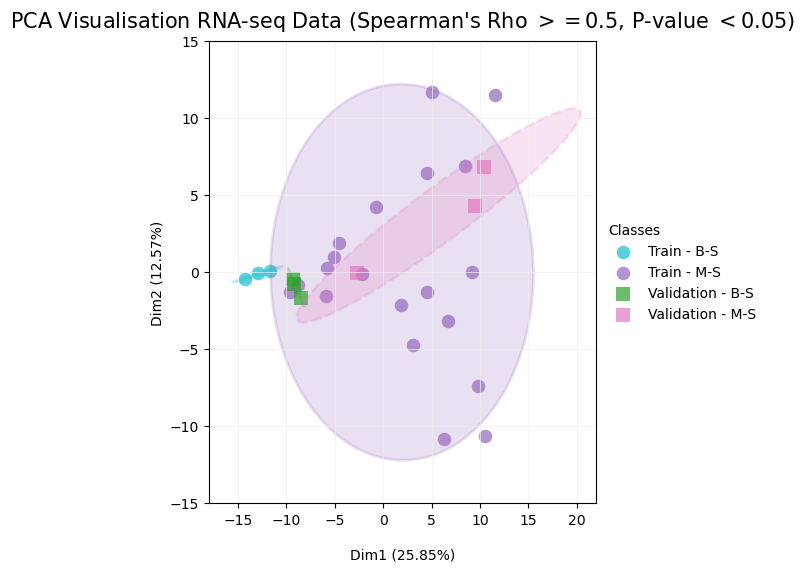

In [130]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours_train = ("#17BECF", "#9467BD")
colours_test = ("#2CA02C", "#E377C2")

# Train data
for target, colour in zip(targets, colours_train):

    # Sort data by class
    indicesToKeep = df_rna_train_pca_class["SURGICAL"] == target
    xdata = df_rna_train_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rna_train_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label="Train - " + target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points

# Test data    
for target, colour in zip(targets, colours_test):

    # Sort data by class
    indicesToKeep = df_rna_test_pca_class["SURGICAL"] == target
    xdata = df_rna_test_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rna_test_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, linestyle="--", alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label="Validation - " + target, # use labels provided above
               c=colour, # use colors provided above
               marker="s",
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation RNA-seq Data (Spearman's Rho $ >= 0.5$, P-value $ < 0.05$)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(rna_spear_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-18,22)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(rna_spear_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-15,15)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

#### t-SNE

In [131]:
rna_train_comps, rna_train_var = cumulative_variance(rna_train_spear)

In [132]:
variance_df = pd.DataFrame(
    {
        "Number of Components": map(str, rna_train_comps),
        "Cumulative Variance": rna_train_var
    }
)

variance_df

,Number of Components,Cumulative Variance
0,1,25.85
1,2,38.42
2,3,47.22
3,4,55.32
4,5,61.75


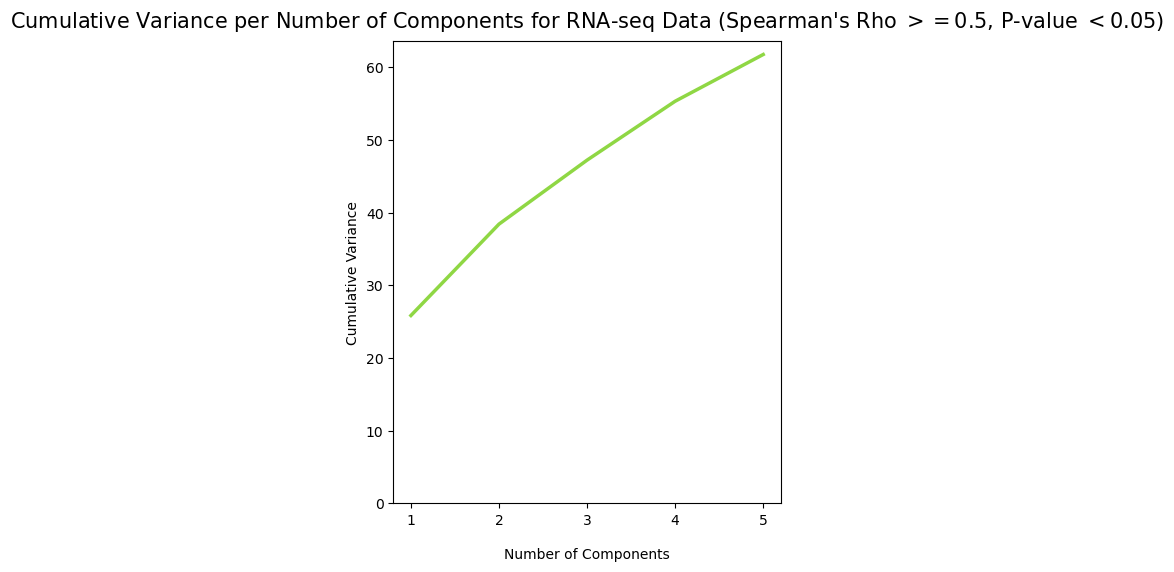

In [133]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.plot(variance_df["Number of Components"], variance_df["Cumulative Variance"], color="#8FD744FF", linewidth=2.5)
ax.set_title("Cumulative Variance per Number of Components for RNA-seq Data (Spearman's Rho $ >= 0.5$, P-value $ < 0.05$)", fontsize = 15, pad=10)
ax.set_xlabel("Number of Components", fontsize=10, labelpad=15)
ax.set_ylim(ymin=0)
ax.set_ylabel("Cumulative Variance", fontsize=10)
plt.show()

In [134]:
# Seperating out the features
rna_train_spear = rna_train_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
rna_train_spear = rna_train_spear.loc[:, rna_train_spear.columns.isin(spearman_rna)]
# Seperating out the target
rna_train_class = rna_train_df[["SURGICAL"]]

# Create PCA with 2 components
rna_spear_pca = PCA(n_components=4)
rna_train_spear_prinComps = rna_spear_pca.fit_transform(rna_train_spear)

# Print DataFrame
df_rna_train_princComps = pd.DataFrame(data=rna_train_spear_prinComps, columns=["Principal Component 1", "Principal Component 2", "Principal Component 3", "Principal Component 4"])
df_rna_train_princComps

,Principal Component 1,Principal Component 2,Principal Component 3,Principal Component 4
0,-5.096833,0.997949,1.214785,-0.369776
1,11.564294,11.553006,-5.220381,-3.510954
2,6.271019,-10.808852,-8.633868,7.590926
3,10.507070,-10.606647,0.547950,-4.550205
4,-4.509068,1.909222,-2.150858,0.434981
5,9.192113,0.033136,-0.076492,3.187964
6,-9.661241,-1.276639,-1.245958,-0.038172
7,4.563032,6.431911,15.160621,7.915642
8,-14.260530,-0.414119,-0.109950,-1.667999
9,-2.214691,-0.082223,4.811307,2.890913


In [135]:
# Percentage explained by each component
print(rna_spear_pca.explained_variance_ratio_)

[0.25846348 0.12574327 0.08803427 0.08098228]


In [136]:
# Final dataframe for plotting the data for class
df_rna_train_spear_class = pd.concat([df_rna_train_princComps, rna_train_class], axis=1)

In [137]:
# Seperating out the features
rna_test_spear = rna_test_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
rna_test_spear = rna_test_spear.loc[:, rna_test_spear.columns.isin(spearman_rna)]
# Seperating out the target
rna_test_class = rna_test_df[["SURGICAL"]]

# Create PCA with 2 components
rna_test_spear_prinComps = rna_spear_pca.transform(rna_test_spear)

# Print DataFrame
df_rna_test_princComps = pd.DataFrame(data=rna_test_spear_prinComps, columns=["Principal Component 1", "Principal Component 2", "Principal Component 3", "Principal Component 4"])
df_rna_test_princComps

,Principal Component 1,Principal Component 2,Principal Component 3,Principal Component 4
0,10.442003,6.846282,-4.140572,-2.064115
1,-9.156196,-0.780532,-1.363929,-1.027503
2,-8.499343,-1.681048,-2.545458,0.500949
3,-9.307977,-0.441684,-0.024471,-0.956861
4,9.466755,4.290672,-1.252304,0.284056
5,-2.721215,-0.025523,2.909025,0.506269


In [138]:
# Percentage explained by each component
print(rna_spear_pca.explained_variance_ratio_)

[0.25846348 0.12574327 0.08803427 0.08098228]


In [139]:
# Final dataframe for plotting the data for class
df_rna_test_spear_class = pd.concat([df_rna_test_princComps, rna_test_class], axis=1)

In [140]:
# Final dataframe for t-SNE plot 
df_rna_spear_all = pd.concat([df_rna_train_spear_class, df_rna_test_spear_class], ignore_index=True)
df_rna_spear_all

,Principal Component 1,Principal Component 2,Principal Component 3,Principal Component 4,SURGICAL
0,-5.096833,0.997949,1.214785,-0.369776,M-S
1,11.564294,11.553006,-5.220381,-3.510954,M-S
2,6.271019,-10.808852,-8.633868,7.590926,M-S
3,10.507070,-10.606647,0.547950,-4.550205,M-S
4,-4.509068,1.909222,-2.150858,0.434981,M-S
5,9.192113,0.033136,-0.076492,3.187964,M-S
6,-9.661241,-1.276639,-1.245958,-0.038172,M-S
7,4.563032,6.431911,15.160621,7.915642,M-S
8,-14.260530,-0.414119,-0.109950,-1.667999,B-S
9,-2.214691,-0.082223,4.811307,2.890913,M-S


In [141]:
# Seperating out the features
rna_all = df_rna_spear_all.drop(["SURGICAL"], axis=1)
# Seperating out the target
rna_class = df_rna_spear_all[["SURGICAL"]]

Determine perplexity to use for t-SNE:

In [142]:
perplexities = np.arange(1, 29)
KL_divergences = []

for i in perplexities:
    # Create tSNE embedding with 2 dimensions
    tsne = TSNE(n_components=2, verbose=0, perplexity=i, n_iter=5000)
    tsne_results = tsne.fit_transform(rna_all)
    tsne_div = tsne.kl_divergence_
    # Add divergence to array
    KL_divergences.append(tsne_div)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and w

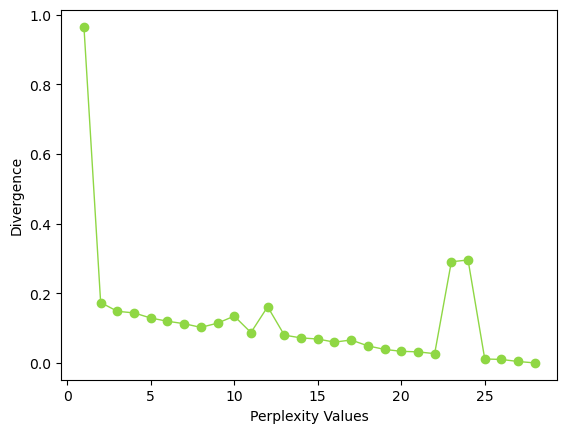

In [143]:
plt.plot(perplexities, KL_divergences, marker="o", color="#8FD744FF", linewidth=1)
plt.xlabel("Perplexity Values")
plt.ylabel("Divergence")

plt.show()

In [144]:
# Create tSNE embedding with 2 dimensions
time_start = time.time()
rna_tsne = TSNE(n_components=2, verbose=1, perplexity=28, n_iter=5000)
rna_tsne_results = rna_tsne.fit_transform(rna_all)

print('t-SNE done! Time elapsed: {} seconds'.format(time.time()-time_start))

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 28 nearest neighbors...
[t-SNE] Indexed 29 samples in 0.000s...
[t-SNE] Computed neighbors for 29 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 29 / 29
[t-SNE] Mean sigma: 220.753024
[t-SNE] KL divergence after 250 iterations with early exaggeration: 41.856342
[t-SNE] KL divergence after 750 iterations: 0.000037
t-SNE done! Time elapsed: 0.12206125259399414 seconds


In [145]:
# Create DataFrame of tSNE results
df_rna_tsne_class = pd.DataFrame()
df_rna_tsne_class["tsne_one"] = rna_tsne_results[:,0]
df_rna_tsne_class["tsne_two"] = rna_tsne_results[:,1]
df_rna_tsne_class["SURGICAL"] = rna_class

df_rna_tsne_class

,tsne_one,tsne_two,SURGICAL
0,0.456688,-0.147206,M-S
1,0.447822,-0.062419,M-S
2,0.524420,-0.107940,M-S
3,0.513041,-0.088512,M-S
4,0.456531,-0.144991,M-S
5,0.484150,-0.079940,M-S
6,0.461631,-0.156291,M-S
7,0.420676,-0.082311,M-S
8,0.451033,-0.168452,B-S
9,0.461772,-0.138622,M-S


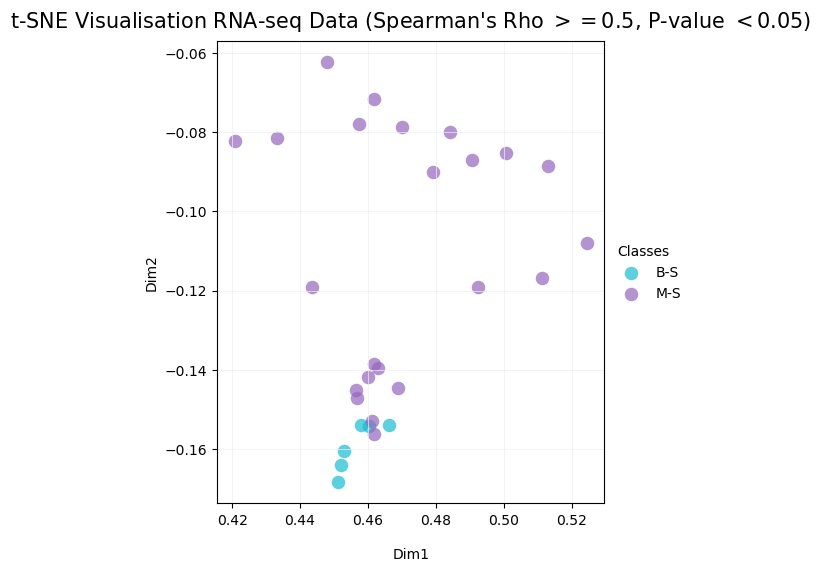

In [146]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rna_tsne_class["SURGICAL"] == target
    xdata = df_rna_tsne_class.loc[indicesToKeep, "tsne_one"]
    ydata = df_rna_tsne_class.loc[indicesToKeep, "tsne_two"]

    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("t-SNE Visualisation RNA-seq Data (Spearman's Rho $ >= 0.5$, P-value $ < 0.05$)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1', fontsize=10, labelpad=15)
ax.set_ylabel('Dim2', fontsize=10)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

#### UMAP

In [147]:
# Seperating out the features
rna_all = df_rna_spear_all.drop(["SURGICAL"], axis=1)
# Seperating out the target
rna_class = df_rna_spear_all[["SURGICAL"]]

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


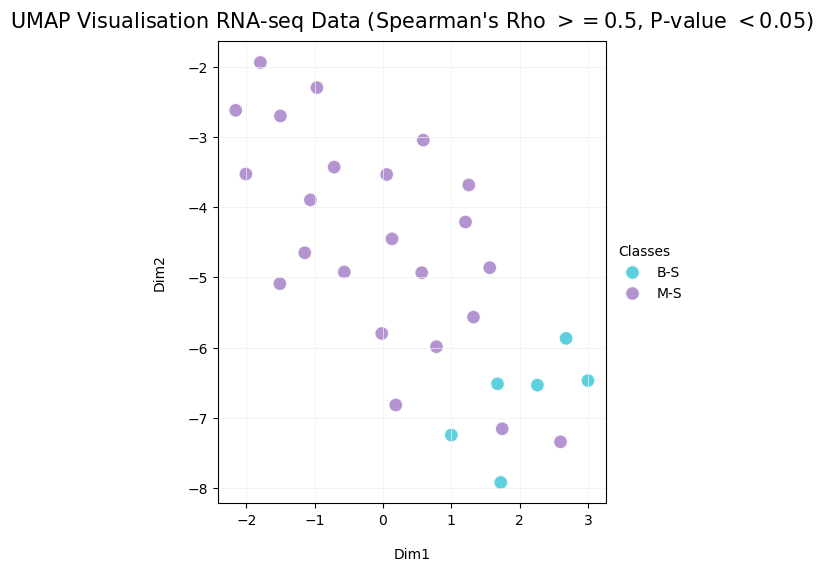

In [148]:
draw_umap_rna_class(n_neighbors=50, min_dist=0.5, title="UMAP Visualisation RNA-seq Data (Spearman's Rho $ >= 0.5$, P-value $ < 0.05$)", num_features=rna_all)